# Combining Two Papers: Classical Bioinformatics vs. Graph-CNN + GLRP, on the Same Breast Cancer Data

This notebook takes the **data** from Paper 1 and analyzes it with the **methodology of both** Paper 1 and Paper 2 — two independent lenses on the same real patients, run side by side, then directly compared.

**Paper 1:** Wu YN, Yu CC, Hu KM, Zhang SZ. *Prominin-1 (PROM1) Significantly Correlated With Bone Metastasis and Influenced Prognosis in Breast Cancer.* Research Square, 2021. — a classical bioinformatics pipeline: differential expression → PPI hub genes → Cox/Kaplan-Meier survival analysis, identifying **PROM1** and **CCL2** as prognostic biomarkers.

**Paper 2:** Chereda H, et al. *Explaining decisions of graph convolutional neural networks: patient-specific molecular subnetworks responsible for metastasis prediction in breast cancer.* Genome Medicine, 2021. — a deep learning pipeline: a Graph Convolutional Neural Network (Graph-CNN) trained on gene expression structured by a protein-protein interaction (PPI) network, explained per-patient by **Graph Layer-wise Relevance Propagation (GLRP)**.

**The question this notebook asks:** if we point Paper 2's deep-learning explainability machinery at Paper 1's actual dataset, does it independently rediscover what Paper 1's classical statistics found? Two genuinely different methods, same real patients — do they agree?

## The data (all real, all fetched live by code below — nothing simulated)

| Dataset | Role |
|---|---|
| **GSE175692** | The core dataset both methodologies run on: 184 metastatic breast cancer patients, 771-gene NanoString panel, real bone-vs-other-organ metastasis labels, real overall survival data |
| **GSE14020** | Independent validation of hub-gene expression (Paper 1's validation step) |
| **GSE124647** | Independent prognosis verification (Paper 1's validation step) |
| **GSE11121** | Independent distant-metastasis-free-survival verification (Paper 1's validation step) |
| **STRING** (PPI network) | Real, live protein-protein interaction database — used by both methodologies here (the PROM1 paper used it directly; it substitutes for the GLRP paper's offline HPRD database, per our earlier work) |

## Two classification tasks for the Graph-CNN + GLRP side

Since you asked for **both**, GSE175692 is analyzed by Paper 2's method twice, on two different real labels:

- **Task 1 — bone metastasis vs. other-organ metastasis**: Paper 1's own original classification task on this dataset (33 vs. 151 patients).
- **Task 2 — survival outcome**: a metastasis-prediction-style label in the spirit of Paper 2's original task, built from GSE175692's real overall-survival data (death within N years vs. alive with sufficient follow-up). Framed honestly: because every patient in GSE175692 already *has* metastatic disease (these are biopsies from metastatic sites), this label is about **survival outcome among metastatic patients**, not the original *onset* of metastasis that Paper 2's paper predicted — the closest real, honest equivalent available in this specific dataset.

## What you'll see in every section

Every step shows its **input data as a real table**, its **code**, and its **output** — both as printed/displayed tables and as plots — rendered directly in the notebook's output cells (not just described in text), plus a final synthesis section putting every method's verdict on the same genes side by side.


## 0. Keyword glossary

*(Builds on our two earlier notebooks — kept concise here; see those notebooks for the full walkthroughs of each individual method.)*

| Term | Meaning |
|---|---|
| **DEG (Differentially Expressed Gene)** | A gene whose expression differs significantly between two groups (Paper 1's method). |
| **PPI network / hub gene** | A protein-protein interaction graph; a "hub gene" has many connections in it. |
| **Cox regression / HR / Kaplan-Meier** | Survival-analysis tools relating a variable to patient outcome over time; HR (hazard ratio) > 1 means worse prognosis. |
| **Risk score model** | A combined score from multiple genes' Cox coefficients, stratifying patients into high/low risk. |
| **Graph-CNN** | A neural network that convolves over graph-structured data (genes connected by PPI edges) rather than grid-structured data (image pixels). |
| **Chebyshev spectral filter** | The specific, efficient graph-convolution mechanism both the Graph-CNN paper and this notebook use. |
| **GLRP (Graph Layer-wise Relevance Propagation)** | Paper 2's method for explaining *which genes* drove one specific patient's Graph-CNN prediction. |
| **Relevance / |relevance|** | GLRP's per-gene importance score for one patient's prediction; can be positive or negative, ranked by magnitude for subnetwork construction. |
| **Patient-specific subnetwork** | The most-relevant genes for one patient's prediction, visualized as a PPI subgraph. |
| **AUC / F1 / Youden threshold** | Standard classification-performance metrics; Youden's threshold is the calibration point that best balances true/false positive rates for imbalanced classes. |
| **Cross-method overlap / synthesis** | This notebook's new contribution: directly comparing which genes each method (classical stats vs. deep learning explainability) flags as important, for the same real patients. |


## 1. Setup


In [1]:
!pip install -q torch torchvision scipy networkx scikit-learn matplotlib seaborn matplotlib-venn gseapy lifelines pandas numpy requests statsmodels

In [2]:
import os, io, csv, gzip, time, warnings
import requests
import numpy as np
import pandas as pd
import scipy.sparse as sp
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, roc_curve
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.utils import concordance_index

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
torch.manual_seed(0); np.random.seed(0)

DATA_DIR, FIG_DIR, OUT_DIR = "data", "figures", "output"
for d in (DATA_DIR, FIG_DIR, OUT_DIR):
    os.makedirs(d, exist_ok=True)

def download(url, dest, timeout=180):
    if os.path.exists(dest):
        return dest
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    with open(dest, "wb") as f:
        f.write(r.content)
    return dest

HUB_GENES = ["MMP9", "ITGB3", "BMP2", "CCL2", "PROM1"]  # Paper 1's 5 reported hub genes
print("Setup complete.")

/private/tmp/claude-501/-Users-soumyasriperepu-researchAgent/0a56c649-bbfd-4147-b66a-91f9bc359cd5/scratchpad/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Setup complete.


## 2. Data acquisition

The same robust GEO series-matrix parser from our earlier notebooks (it keys each clinical-metadata cell by its own field label rather than trusting row position — some GEO series have per-sample field reordering that a naive parser would silently mislabel).


In [3]:
def parse_series_matrix(path):
    opener = gzip.open if str(path).endswith(".gz") else open
    with opener(path, "rt", encoding="latin-1") as f:
        lines = f.read().splitlines()
    meta, table_start, table_end = {}, None, None
    for i, line in enumerate(lines):
        if line.startswith("!series_matrix_table_begin"):
            table_start = i + 1
        elif line.startswith("!series_matrix_table_end"):
            table_end = i
        elif line.startswith("!"):
            parts = next(csv.reader([line], delimiter="\t"))
            meta.setdefault(parts[0].lstrip("!"), []).append(parts[1:])
    geo_acc = meta["Sample_geo_accession"][0]
    n_samples = len(geo_acc)
    records = {s: {} for s in geo_acc}
    for row in meta.get("Sample_characteristics_ch1", []):
        for j, cell in enumerate(row):
            if j >= n_samples:
                continue
            if ":" in cell:
                field, val = cell.split(":", 1)
                field, val = field.strip(), val.strip()
            else:
                field, val = "characteristic", cell.strip()
            records[geo_acc[j]].setdefault(field, val)
    clinical = pd.DataFrame.from_dict(records, orient="index").reindex(geo_acc)
    if "Sample_source_name_ch1" in meta:
        clinical.insert(0, "source_name", meta["Sample_source_name_ch1"][0])
    if "Sample_title" in meta:
        clinical.insert(0, "title", meta["Sample_title"][0])
    table_text = "\n".join(lines[table_start:table_end])
    expr = pd.read_csv(io.StringIO(table_text), sep="\t", index_col=0)
    expr.columns = [c.strip('"') for c in expr.columns]
    expr.index = [str(i).strip('"') for i in expr.index]
    return expr, clinical

GEO_FILES = {
    "GSE175692": "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE175nnn/GSE175692/matrix/GSE175692_series_matrix.txt.gz",
    "GSE14020-GPL96":  "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE14nnn/GSE14020/matrix/GSE14020-GPL96_series_matrix.txt.gz",
    "GSE14020-GPL570": "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE14nnn/GSE14020/matrix/GSE14020-GPL570_series_matrix.txt.gz",
    "GSE124647": "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE124nnn/GSE124647/matrix/GSE124647_series_matrix.txt.gz",
    "GSE11121":  "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE11nnn/GSE11121/matrix/GSE11121_series_matrix.txt.gz",
}
geo_data = {}
for name, url in GEO_FILES.items():
    path = download(url, f"{DATA_DIR}/{name}.txt.gz")
    expr, clin = parse_series_matrix(path)
    geo_data[name] = (expr, clin)
    print(f"{name}: expression {expr.shape}, clinical {clin.shape}")

expr175, clin175 = geo_data["GSE175692"]
expr175 = expr175.astype(float)

GSE175692: expression (771, 184), clinical (184, 30)
GSE14020-GPL96: expression (22283, 36), clinical (36, 3)


GSE14020-GPL570: expression (54675, 29), clinical (29, 3)


GSE124647: expression (22283, 140), clinical (140, 18)


GSE11121: expression (22283, 200), clinical (200, 9)


**Input data preview** — the core dataset's expression matrix and clinical annotations, shown as real tables (not just described):

In [4]:
print("GSE175692 expression matrix (genes x patients), first 8 genes x 6 patients:")
display(expr175.iloc[:8, :6])

print("\\nGSE175692 clinical annotations, first 6 patients:")
display(clin175[["organ", "ose", "os (months) since dxmet", "hr", "her2"]].head(6))

GSE175692 expression matrix (genes x patients), first 8 genes x 6 patients:


,GSM5344040,GSM5344041,GSM5344042,GSM5344043,GSM5344044,GSM5344045
ABCA8,-6.931207,-4.394252,-5.883736,-5.507928,-5.036740,-6.650649
ABCF1,-2.024316,-1.876404,-2.848112,-1.823927,-2.320533,-2.209214
ACTR3B,-3.293777,-2.531755,-3.347683,-2.122550,-3.522166,-4.980798
ACVR1B,-3.332947,-2.153244,-3.161270,-2.087658,-2.756632,-3.540225
ACVR1C,-7.779203,-6.268721,-5.620701,-9.519155,-5.036740,-6.940156
ACVRL1,-4.428706,-2.809289,-4.746232,-4.519155,-4.674170,-2.779164
ADAM12,-3.414631,-4.268721,-4.505224,-4.686265,-5.259132,-0.378762
ADCY9,-1.425175,-2.496131,-3.076381,-2.045449,-2.229385,-3.110081


\nGSE175692 clinical annotations, first 6 patients:


,organ,ose,os (months) since dxmet,hr,her2
GSM5344040,Bone,0,18.61,POS,NEG
GSM5344041,Lung,1,14.14,POS,NEG
GSM5344042,Lymph node,0,14.40,POS,NEG
GSM5344043,Bone,1,28.60,POS,NEG
GSM5344044,Bone,0,91.99,POS,NEG
GSM5344045,Bone,0,65.00,POS,NEG


### PPI network (STRING) restricted to GSE175692's 771-gene panel

Both papers ultimately rely on the same kind of real network resource here: Paper 1 queried STRING directly; Paper 2's HPRD substitute (from our earlier reproduction) was also STRING — so this is a single, consistent, real PPI backbone for the entire combined analysis.


In [5]:
STRING_LINKS_URL = "https://stringdb-downloads.org/download/protein.links.v12.0/9606.protein.links.v12.0.txt.gz"
STRING_INFO_URL = "https://stringdb-downloads.org/download/protein.info.v12.0/9606.protein.info.v12.0.txt.gz"
links_path = download(STRING_LINKS_URL, f"{DATA_DIR}/string_links.txt.gz")
info_path = download(STRING_INFO_URL, f"{DATA_DIR}/string_info.txt.gz")

info = pd.read_csv(info_path, sep="\t", compression="gzip")
ensp2sym = dict(zip(info["#string_protein_id"], info["preferred_name"]))
links = pd.read_csv(links_path, sep=" ", compression="gzip")
links_hc = links[links["combined_score"] >= 400].copy()
links_hc["sym1"] = links_hc["protein1"].map(ensp2sym)
links_hc["sym2"] = links_hc["protein2"].map(ensp2sym)
links_hc = links_hc.dropna(subset=["sym1", "sym2"])

array_genes = set(expr175.index)
edges_restricted = links_hc[links_hc["sym1"].isin(array_genes) & links_hc["sym2"].isin(array_genes)]
G_full = nx.from_pandas_edgelist(edges_restricted, "sym1", "sym2")
G_full.add_nodes_from(array_genes)
main_cc = max(nx.connected_components(G_full), key=len)
G_main = G_full.subgraph(main_cc).copy()
gene_list = sorted(G_main.nodes())
A = nx.to_scipy_sparse_array(G_main, nodelist=gene_list, format="csr")

print(f"STRING edges at medium confidence (>=400): {len(links_hc)}")
print(f"PPI graph restricted to the 771-gene panel: {G_full.number_of_nodes()} nodes total")
print(f"Main connected component (used throughout this notebook): {G_main.number_of_nodes()} nodes, {G_main.number_of_edges()} edges")
print(f"Paper 1's 5 hub genes present in this graph: {[g for g in HUB_GENES if g in gene_list]}")

pd.DataFrame({"gene": gene_list}).to_csv(f"{DATA_DIR}/gene_list.txt", index=False, header=False)
sp.save_npz(f"{DATA_DIR}/ppi_adjacency.npz", A)

STRING edges at medium confidence (>=400): 1858944
PPI graph restricted to the 771-gene panel: 771 nodes total
Main connected component (used throughout this notebook): 737 nodes, 19902 edges
Paper 1's 5 hub genes present in this graph: ['MMP9', 'ITGB3', 'BMP2', 'CCL2', 'PROM1']


# Part A — Paper 1's methodology: classical differential expression + survival statistics

Steps 3-8 below reproduce Paper 1's pipeline exactly as in our earlier standalone reproduction, run here on the same GSE175692 data that Part B will also use — so both parts start from the identical input.


## 3. Differential expression: bone vs. non-bone metastasis

Welch's t-test per gene + Benjamini-Hochberg FDR correction, threshold `P<0.05` and `|logFC|>1` (Paper 1's exact threshold; original paper used R's `limma`, we use a transparent from-scratch equivalent, as before).


In [6]:
bone_mask = clin175["organ"] == "Bone"
bone_samples, other_samples = clin175.index[bone_mask], clin175.index[~bone_mask]
print(f"Bone metastasis: {bone_mask.sum()} patients | Other-organ metastasis: {(~bone_mask).sum()} patients")

deg_rows = []
for gene in expr175.index:
    a = expr175.loc[gene, bone_samples]
    b = expr175.loc[gene, other_samples]
    logfc = a.mean() - b.mean()
    _, p = stats.ttest_ind(a, b, equal_var=False)
    deg_rows.append((gene, logfc, p))
deg = pd.DataFrame(deg_rows, columns=["gene", "logFC", "pvalue"])
deg["FDR"] = multipletests(deg["pvalue"], method="fdr_bh")[1]
deg_sig = deg[(deg["pvalue"] < 0.05) & (deg["logFC"].abs() > 1)].copy()
print(f"Significant DEGs: {len(deg_sig)} (up: {(deg_sig.logFC>0).sum()}, down: {(deg_sig.logFC<0).sum()})")

top_up = deg_sig.sort_values("logFC", ascending=False).head(10)
top_down = deg_sig.sort_values("logFC").head(10)
top20 = pd.concat([top_up, top_down])
deg_sig.to_csv(f"{OUT_DIR}/DEGs_GSE175692.csv", index=False)

print("\\nTop 10 up-regulated and top 10 down-regulated DEGs:")
display(pd.concat([top_up.assign(direction="UP"), top_down.assign(direction="DOWN")])[["gene","logFC","pvalue","FDR","direction"]].reset_index(drop=True))

Bone metastasis: 33 patients | Other-organ metastasis: 151 patients


Significant DEGs: 78 (up: 61, down: 17)


\nTop 10 up-regulated and top 10 down-regulated DEGs:


,gene,logFC,pvalue,FDR,direction
0,IBSP,5.239913,1.629313e-11,NaN,UP
1,HBB,4.830262,1.265687e-07,NaN,UP
2,CHAD,4.106619,2.098043e-09,NaN,UP
3,WIF1,4.057325,1.124965e-09,NaN,UP
4,MMP9,3.609914,3.976255e-10,NaN,UP
5,VIT,2.426797,5.005242e-08,NaN,UP
6,EYA1,2.403626,4.358442e-09,NaN,UP
7,ITGB3,2.100035,3.434211e-09,NaN,UP
8,CEACAM6,1.952421,1.481136e-03,NaN,UP
9,CEACAM5,1.909538,1.208860e-03,NaN,UP


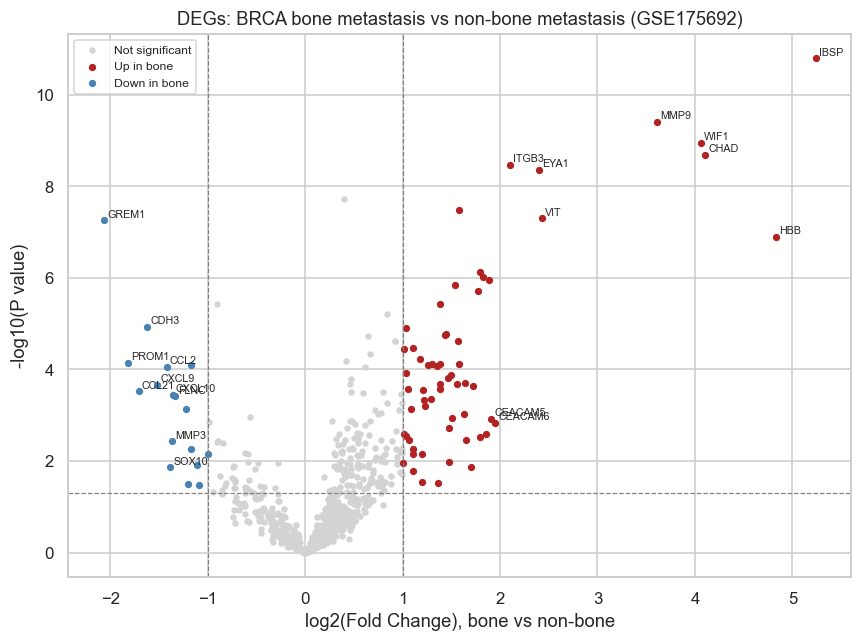

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
deg["neglogp"] = -np.log10(deg["pvalue"])
not_sig = deg[~deg["gene"].isin(deg_sig["gene"])]
ax.scatter(not_sig["logFC"], not_sig["neglogp"], s=10, color="lightgrey", label="Not significant")
ax.scatter(deg_sig.loc[deg_sig.logFC > 0, "logFC"], -np.log10(deg_sig.loc[deg_sig.logFC > 0, "pvalue"]), s=14, color="firebrick", label="Up in bone")
ax.scatter(deg_sig.loc[deg_sig.logFC < 0, "logFC"], -np.log10(deg_sig.loc[deg_sig.logFC < 0, "pvalue"]), s=14, color="steelblue", label="Down in bone")
for _, row in top20.iterrows():
    ax.annotate(row["gene"], (row["logFC"], -np.log10(row["pvalue"])), fontsize=7, xytext=(2, 2), textcoords="offset points")
ax.axvline(1, ls="--", color="grey", lw=0.8); ax.axvline(-1, ls="--", color="grey", lw=0.8)
ax.axhline(-np.log10(0.05), ls="--", color="grey", lw=0.8)
ax.set_xlabel("log2(Fold Change), bone vs non-bone"); ax.set_ylabel("-log10(P value)")
ax.set_title("DEGs: BRCA bone metastasis vs non-bone metastasis (GSE175692)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/01_volcano_plot.png"); plt.show()

## 4. Functional enrichment (KEGG, via Enrichr)

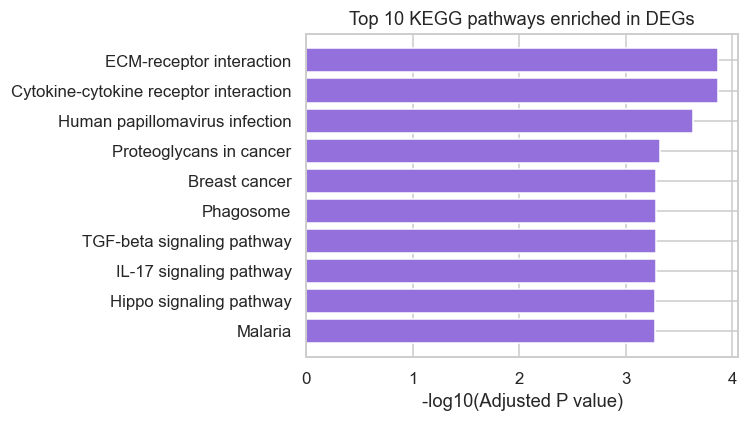

,Term,Overlap,Adjusted P-value,Genes
0,ECM-receptor interaction,6/88,0.000137,COMP;IBSP;ITGB3;CHAD;SPP1;CD36
1,Cytokine-cytokine receptor interaction,9/295,0.000137,CXCL10;CXCL9;BMP2;CCL21;LEPR;BMP8A;CCL2;LIFR;BMP5
2,Human papillomavirus infection,9/331,0.000233,COMP;LFNG;IBSP;WNT5B;ITGB3;CHAD;SPP1;FZD8;WNT2
3,Proteoglycans in cancer,7/205,0.000478,WNT5B;ITGB3;FZD8;FLNC;MMP9;WNT2;ESR1
4,Breast cancer,6/147,0.000518,FGF7;WNT5B;FZD8;PGR;WNT2;ESR1
5,Phagosome,6/152,0.000518,COMP;COLEC12;MARCO;ITGB3;CD36;HLA-DQA1
6,TGF-beta signaling pathway,5/94,0.000518,GREM1;BMP2;BAMBI;BMP8A;BMP5
7,IL-17 signaling pathway,5/94,0.000518,CXCL10;MMP3;CCL2;MMP9;S100A7
8,Hippo signaling pathway,6/163,0.000532,BMP2;WNT5B;BMP8A;FZD8;WNT2;BMP5
9,Malaria,4/50,0.000532,COMP;HBB;CCL2;CD36


In [8]:
import gseapy as gp

def enrichr_retry(gene_list_, gene_sets, retries=6, base_delay=8):
    for attempt in range(retries):
        try:
            return gp.enrichr(gene_list=gene_list_, gene_sets=gene_sets, outdir=None).results
        except Exception as e:
            if attempt == retries - 1:
                raise
            print(f"Enrichr request failed ({e}); retrying in {base_delay*(attempt+1)}s...")
            time.sleep(base_delay * (attempt + 1))

deg_gene_list = deg_sig["gene"].tolist()
kegg_res = enrichr_retry(deg_gene_list, ["KEGG_2021_Human"]).sort_values("Adjusted P-value").head(10)

fig, ax = plt.subplots(figsize=(7, 4))
plot_df = kegg_res.iloc[::-1]
ax.barh(plot_df["Term"], -np.log10(plot_df["Adjusted P-value"]), color="mediumpurple")
ax.set_xlabel("-log10(Adjusted P value)"); ax.set_title("Top 10 KEGG pathways enriched in DEGs")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/02_kegg_enrichment.png"); plt.show()
display(kegg_res[["Term", "Overlap", "Adjusted P-value", "Genes"]].reset_index(drop=True))

## 5. PPI network and hub genes (Paper 1's method: STRING among the DEGs specifically)

This constructs a network from just the significant DEGs found above (a *different*, much smaller graph than Part B's full main-component graph, which covers all 771 panel genes) — matching Paper 1's own hub-gene-discovery step exactly.


DEG-restricted PPI network: 78 nodes, 220 edges
\nTop 10 hub genes by degree centrality:


,gene,degree
0,MMP9,26
1,ESR1,26
2,SPP1,19
3,BMP2,18
4,MMP3,16
5,KRT5,16
6,CCL2,14
7,FGF7,13
8,PROM1,13
9,PGR,13


\nData-driven hub-gene shortlist (top-10-by-degree ∩ top-20-by-|logFC|): ['CCL2', 'MMP3', 'MMP9', 'PROM1']
Paper 1's reported 5 hub genes: ['MMP9', 'ITGB3', 'BMP2', 'CCL2', 'PROM1']


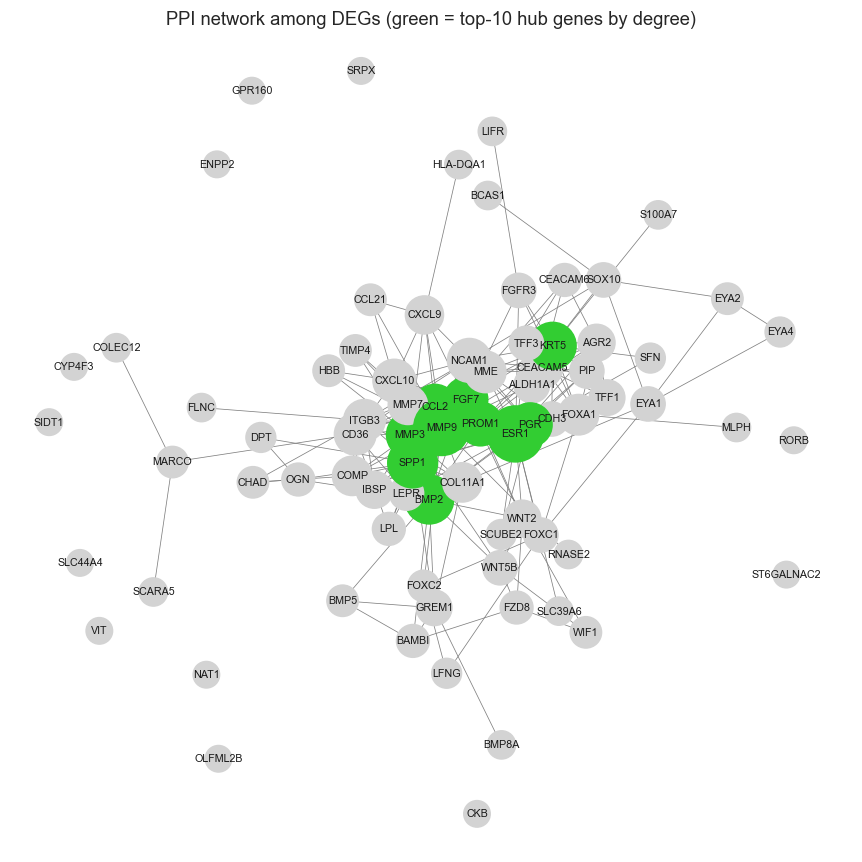

In [9]:
string_url = "https://string-db.org/api/tsv/network"
params = {"identifiers": "%0d".join(deg_gene_list), "species": 9606, "required_score": 400}
r = requests.get(string_url, params=params, timeout=60)
ppi_edges = pd.read_csv(io.StringIO(r.text), sep="\t")

G_deg = nx.Graph()
G_deg.add_nodes_from(deg_gene_list)
for _, row in ppi_edges.iterrows():
    G_deg.add_edge(row["preferredName_A"], row["preferredName_B"])
print(f"DEG-restricted PPI network: {G_deg.number_of_nodes()} nodes, {G_deg.number_of_edges()} edges")

degree_rank = pd.Series(dict(G_deg.degree())).sort_values(ascending=False)
top10_hub = degree_rank.head(10)
print("\\nTop 10 hub genes by degree centrality:")
display(top10_hub.rename("degree").reset_index().rename(columns={"index": "gene"}))

top20_deg_genes = set(top20["gene"])
data_driven_hub = set(top10_hub.index) & top20_deg_genes
print(f"\\nData-driven hub-gene shortlist (top-10-by-degree ∩ top-20-by-|logFC|): {sorted(data_driven_hub)}")
print(f"Paper 1's reported 5 hub genes: {HUB_GENES}")

fig, ax = plt.subplots(figsize=(8, 8))
pos = nx.spring_layout(G_deg, seed=42, k=0.4)
node_colors = ["limegreen" if n in top10_hub.index else "lightgrey" for n in G_deg.nodes()]
node_sizes = [300 + 40 * G_deg.degree(n) for n in G_deg.nodes()]
nx.draw_networkx(G_deg, pos, ax=ax, node_color=node_colors, node_size=node_sizes, font_size=7, edge_color="grey", width=0.5, with_labels=True)
ax.set_title("PPI network among DEGs (green = top-10 hub genes by degree)")
ax.axis("off")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/03_ppi_network.png"); plt.show()

## 6. Hub-gene expression validation (discovery cohort + independent GSE14020 cohort)

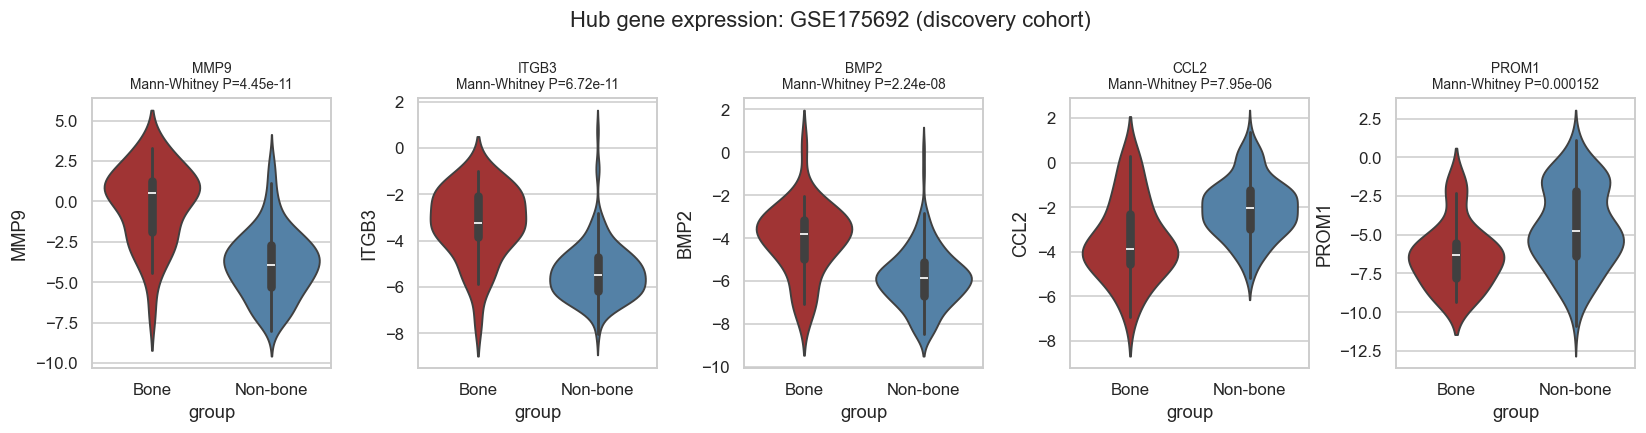

,gene,mean_Bone,mean_Non-bone,pvalue
0,MMP9,-0.221390,-3.831304,4.454949e-11
1,ITGB3,-3.253035,-5.353070,6.720600e-11
2,BMP2,-4.066635,-5.859650,2.240720e-08
3,CCL2,-3.481032,-2.061264,7.946145e-06
4,PROM1,-6.336088,-4.517967,1.516590e-04


In [10]:
def violin_compare(df, genes, group_col, group_labels, title, fname):
    fig, axes = plt.subplots(1, len(genes), figsize=(3 * len(genes), 4))
    stats_rows = []
    for ax, gene in zip(axes, genes):
        sub = df[[gene, group_col]].dropna()
        sns.violinplot(data=sub, x=group_col, y=gene, ax=ax, order=group_labels, palette=["firebrick", "steelblue"], inner="box")
        a = sub.loc[sub[group_col] == group_labels[0], gene]
        b = sub.loc[sub[group_col] == group_labels[1], gene]
        stat, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        ax.set_title(f"{gene}\nMann-Whitney P={p:.3g}", fontsize=9)
        stats_rows.append((gene, a.mean(), b.mean(), p))
    fig.suptitle(title)
    plt.tight_layout(); plt.savefig(f"{FIG_DIR}/{fname}"); plt.show()
    return pd.DataFrame(stats_rows, columns=["gene", f"mean_{group_labels[0]}", f"mean_{group_labels[1]}", "pvalue"])

df175 = expr175.loc[HUB_GENES].T.join(bone_mask.map({True: "Bone", False: "Non-bone"}).rename("group"))
val_175 = violin_compare(df175, HUB_GENES, "group", ["Bone", "Non-bone"], "Hub gene expression: GSE175692 (discovery cohort)", "04_hubgenes_GSE175692.png")
display(val_175)

GSE14020 combined cohort: {'Non-bone': 47, 'Bone': 18}


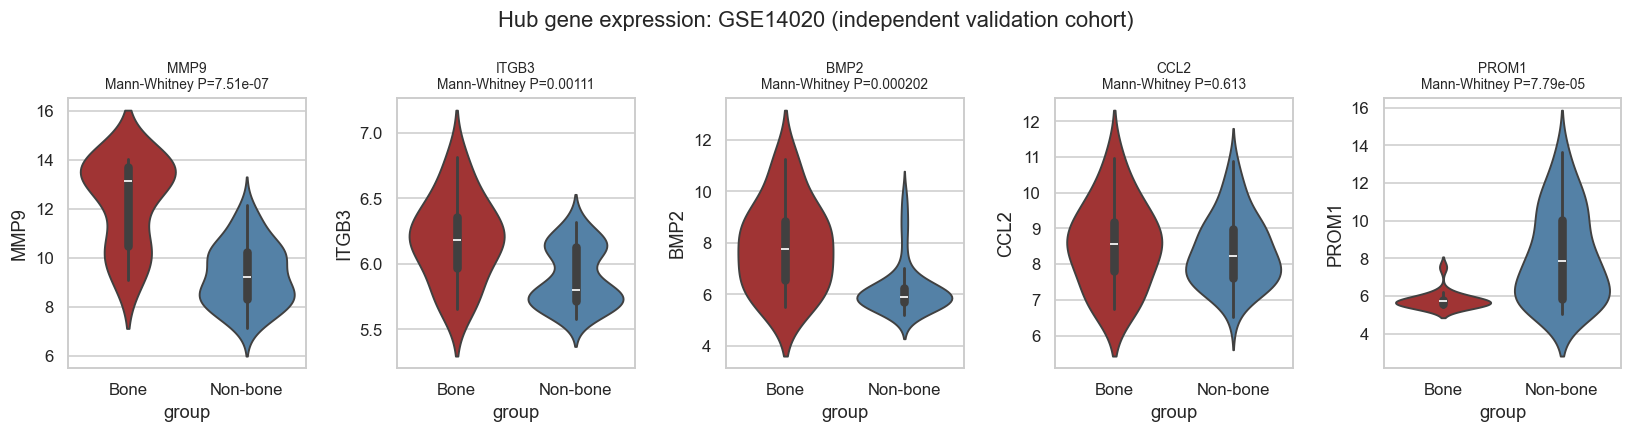

,gene,mean_Bone,mean_Non-bone,pvalue
0,MMP9,12.295444,9.313949,7.507843e-07
1,ITGB3,6.190133,5.899766,1.106892e-03
2,BMP2,7.875267,6.229424,2.021569e-04
3,CCL2,8.537530,8.366409,6.130185e-01
4,PROM1,5.793743,8.117060,7.786908e-05


In [11]:
GPL_ANNOT_URLS = {
    "GPL96": "https://ftp.ncbi.nlm.nih.gov/geo/platforms/GPLnnn/GPL96/annot/GPL96.annot.gz",
    "GPL570": "https://ftp.ncbi.nlm.nih.gov/geo/platforms/GPLnnn/GPL570/annot/GPL570.annot.gz",
}
def load_probe_map(gpl, genes):
    path = download(GPL_ANNOT_URLS[gpl], f"{DATA_DIR}/{gpl}.annot.gz")
    with gzip.open(path, "rt", encoding="latin-1") as f:
        lines = f.read().splitlines()
    start = next(i for i, l in enumerate(lines) if l.startswith("!platform_table_begin")) + 1
    end = next(i for i, l in enumerate(lines) if l.startswith("!platform_table_end"))
    df = pd.read_csv(io.StringIO("\n".join(lines[start:end])), sep="\t", low_memory=False)
    return {g: df.loc[df["Gene symbol"] == g, "ID"].tolist() for g in genes}

def probes_to_gene_level(expr, probe_map):
    out = {}
    for gene, probes in probe_map.items():
        probes = [p for p in probes if p in expr.index]
        if probes:
            out[gene] = expr.loc[probes].astype(float).mean(axis=0)
    return pd.DataFrame(out)

gpl96_map = load_probe_map("GPL96", HUB_GENES)
gpl570_map = load_probe_map("GPL570", HUB_GENES)

expr96, clin96 = geo_data["GSE14020-GPL96"]
expr570, clin570 = geo_data["GSE14020-GPL570"]
g96 = probes_to_gene_level(expr96, gpl96_map)
g570 = probes_to_gene_level(expr570, gpl570_map)
gse14020_expr = pd.concat([g96, g570], axis=0)
gse14020_clin = pd.concat([clin96[["source_name"]], clin570[["source_name"]]], axis=0)
gse14020_clin["group"] = np.where(gse14020_clin["source_name"] == "Bone", "Bone", "Non-bone")
print("GSE14020 combined cohort:", gse14020_clin["group"].value_counts().to_dict())

df14020 = gse14020_expr.join(gse14020_clin["group"])
val_14020 = violin_compare(df14020, HUB_GENES, "group", ["Bone", "Non-bone"], "Hub gene expression: GSE14020 (independent validation cohort)", "05_hubgenes_GSE14020.png")
display(val_14020)

## 7. Prognosis analysis (Cox regression, Kaplan-Meier, risk score, ROC)

Using GSE175692's real overall-survival data across all 184 metastatic patients (the same survival data Task 2 of Part B will also use).


In [12]:
surv175 = clin175[["ose", "os (months) since dxmet"]].copy()
surv175.columns = ["event", "time_months"]
surv175["event"] = pd.to_numeric(surv175["event"], errors="coerce")
surv175["time_months"] = pd.to_numeric(surv175["time_months"], errors="coerce")
surv_df = surv175.join(expr175.loc[HUB_GENES].T).dropna()
print(f"Samples with complete survival + expression data: {len(surv_df)}")

cox_rows = []
for gene in HUB_GENES:
    cph = CoxPHFitter()
    cph.fit(surv_df[["time_months", "event", gene]], duration_col="time_months", event_col="event")
    s = cph.summary.loc[gene]
    cox_rows.append((gene, s["exp(coef)"], s["exp(coef) lower 95%"], s["exp(coef) upper 95%"], s["p"], cph.params_[gene]))
cox_uni = pd.DataFrame(cox_rows, columns=["gene", "HR", "CI_lower", "CI_upper", "pvalue", "coef"])
cox_uni.to_csv(f"{OUT_DIR}/univariate_cox_GSE175692.csv", index=False)
print("Univariate Cox regression, hub genes vs overall survival:")
display(cox_uni[["gene", "HR", "CI_lower", "CI_upper", "pvalue"]])
sig_genes = cox_uni.loc[cox_uni.pvalue < 0.05, "gene"].tolist()
print(f"\\nSignificant prognostic genes (P<0.05): {sig_genes}")

Samples with complete survival + expression data: 180
Univariate Cox regression, hub genes vs overall survival:


,gene,HR,CI_lower,CI_upper,pvalue
0,MMP9,1.043130,0.967912,1.124194,0.268798
1,ITGB3,0.957945,0.826559,1.110214,0.568104
2,BMP2,0.922709,0.804105,1.058806,0.251819
3,CCL2,1.200062,1.050700,1.370656,0.007161
4,PROM1,1.115042,1.033203,1.203363,0.005113


\nSignificant prognostic genes (P<0.05): ['CCL2', 'PROM1']


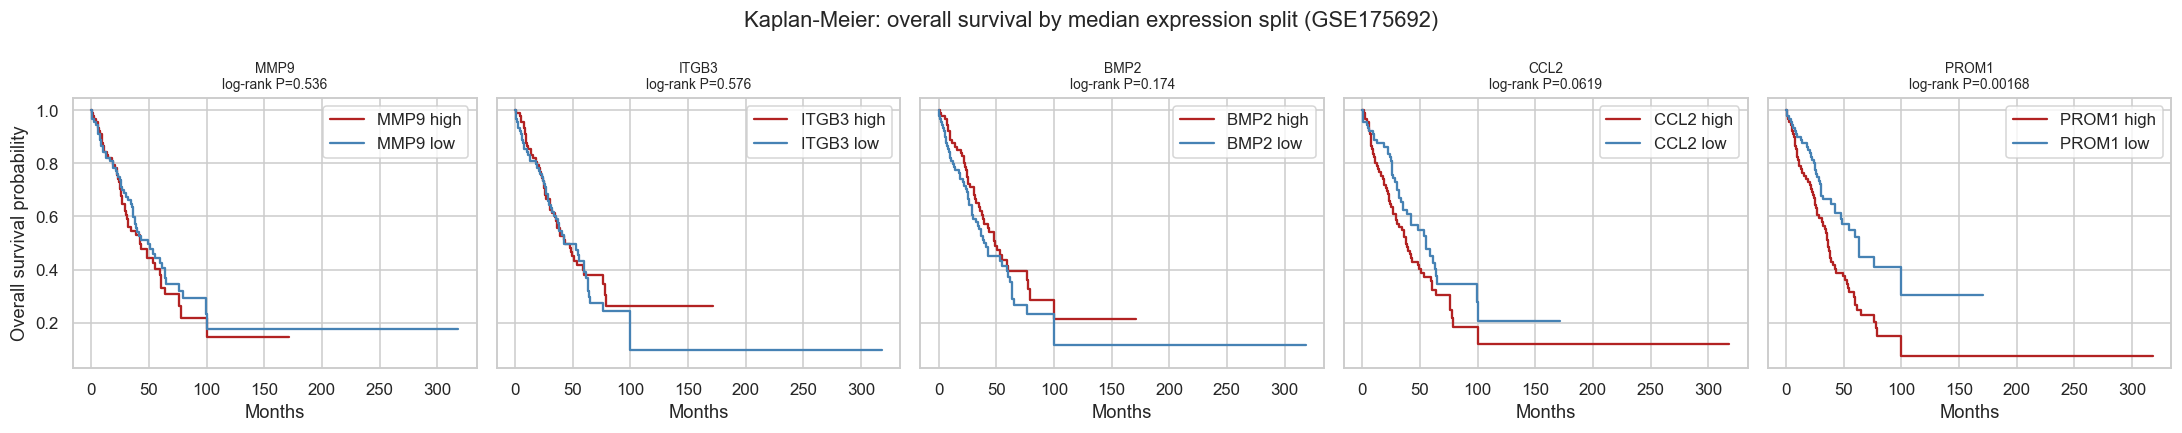

,gene,logrank_pvalue
0,MMP9,0.536061
1,ITGB3,0.576281
2,BMP2,0.174459
3,CCL2,0.061891
4,PROM1,0.001679


In [13]:
fig, axes = plt.subplots(1, len(HUB_GENES), figsize=(4 * len(HUB_GENES), 4), sharey=True)
km_rows = []
for ax, gene in zip(axes, HUB_GENES):
    median = surv_df[gene].median()
    high = surv_df[surv_df[gene] > median]; low = surv_df[surv_df[gene] <= median]
    kmf = KaplanMeierFitter()
    kmf.fit(high["time_months"], high["event"], label=f"{gene} high").plot_survival_function(ax=ax, ci_show=False, color="firebrick")
    kmf.fit(low["time_months"], low["event"], label=f"{gene} low").plot_survival_function(ax=ax, ci_show=False, color="steelblue")
    res = logrank_test(high["time_months"], low["time_months"], high["event"], low["event"])
    ax.set_title(f"{gene}\nlog-rank P={res.p_value:.3g}", fontsize=9); ax.set_xlabel("Months")
    km_rows.append((gene, res.p_value))
axes[0].set_ylabel("Overall survival probability")
plt.suptitle("Kaplan-Meier: overall survival by median expression split (GSE175692)")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/06_km_GSE175692.png"); plt.show()
display(pd.DataFrame(km_rows, columns=["gene", "logrank_pvalue"]))

Multivariate Cox regression (PROM1 + CCL2 together):


,coef,exp(coef),p
covariate,,,
PROM1,0.076807,1.079833,0.074150
CCL2,0.125542,1.133762,0.093252


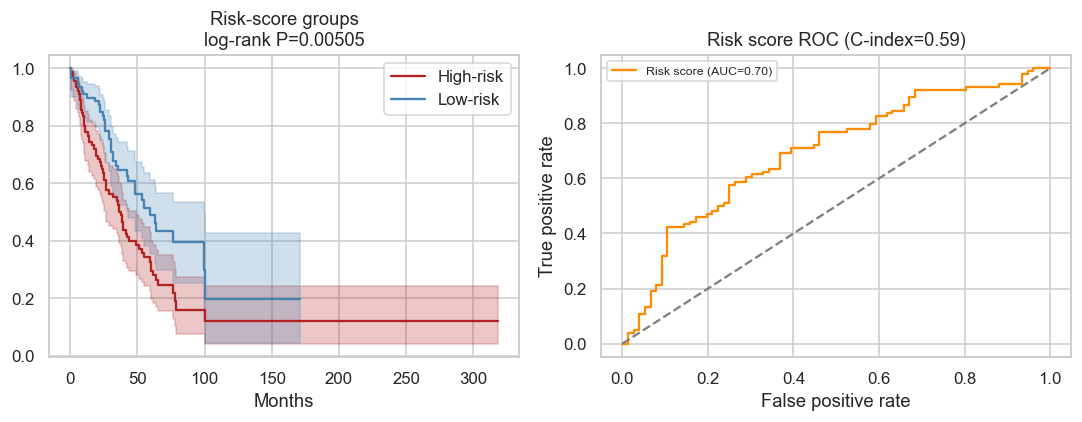

Risk score = 0.07681 x PROM1 + 0.12554 x CCL2  |  log-rank P=0.005055  |  AUC=0.695


In [14]:
cph_multi = CoxPHFitter()
cph_multi.fit(surv_df[["time_months", "event", "PROM1", "CCL2"]], duration_col="time_months", event_col="event")
print("Multivariate Cox regression (PROM1 + CCL2 together):")
display(cph_multi.summary[["coef", "exp(coef)", "p"]])

coef_prom1, coef_ccl2 = cph_multi.params_["PROM1"], cph_multi.params_["CCL2"]
surv_df["risk_score"] = coef_prom1 * surv_df["PROM1"] + coef_ccl2 * surv_df["CCL2"]
median_rs = surv_df["risk_score"].median()
surv_df["risk_group"] = np.where(surv_df["risk_score"] > median_rs, "High-risk", "Low-risk")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
kmf = KaplanMeierFitter()
high = surv_df[surv_df.risk_group == "High-risk"]; low = surv_df[surv_df.risk_group == "Low-risk"]
kmf.fit(high.time_months, high.event, label="High-risk").plot_survival_function(ax=axes[0], color="firebrick")
kmf.fit(low.time_months, low.event, label="Low-risk").plot_survival_function(ax=axes[0], color="steelblue")
res = logrank_test(high.time_months, low.time_months, high.event, low.event)
axes[0].set_title(f"Risk-score groups\nlog-rank P={res.p_value:.3g}"); axes[0].set_xlabel("Months")

fpr, tpr, _ = roc_curve(surv_df["event"], surv_df["risk_score"])
auc_rs = roc_auc_score(surv_df["event"], surv_df["risk_score"])
cindex_rs = concordance_index(surv_df["time_months"], -surv_df["risk_score"], surv_df["event"])
axes[1].plot(fpr, tpr, color="darkorange", label=f"Risk score (AUC={auc_rs:.2f})")
axes[1].plot([0, 1], [0, 1], "--", color="grey")
axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate")
axes[1].set_title(f"Risk score ROC (C-index={cindex_rs:.2f})"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/07_risk_score.png"); plt.show()
print(f"Risk score = {coef_prom1:.5f} x PROM1 + {coef_ccl2:.5f} x CCL2  |  log-rank P={res.p_value:.4g}  |  AUC={auc_rs:.3f}")

## 8. Independent prognosis verification (GSE124647, GSE11121)

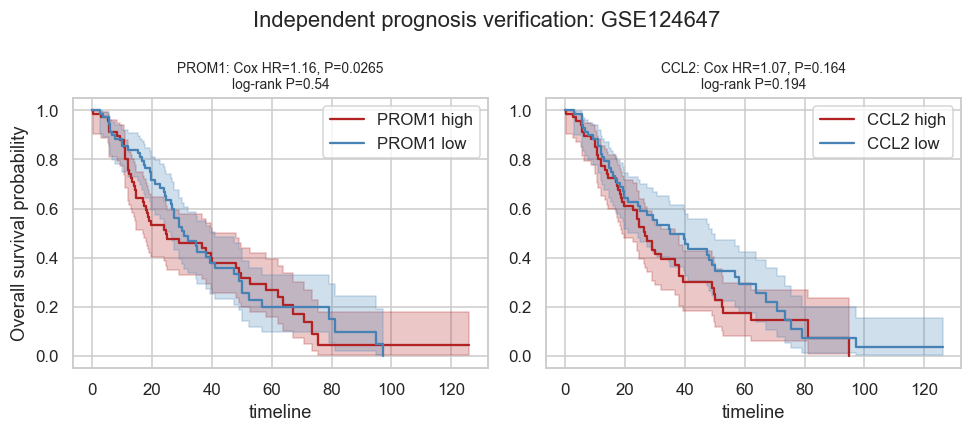

,gene,HR,cox_pvalue,logrank_pvalue
0,PROM1,1.161349,0.026541,0.539581
1,CCL2,1.073391,0.163800,0.194398


In [15]:
expr124, clin124 = geo_data["GSE124647"]
gse124_genes = probes_to_gene_level(expr124, gpl96_map)
surv124 = clin124[["os event", "oas months"]].copy()
surv124.columns = ["event", "time_months"]
surv124["event"] = pd.to_numeric(surv124["event"], errors="coerce")
surv124["time_months"] = pd.to_numeric(surv124["time_months"], errors="coerce")
df124 = surv124.join(gse124_genes[["PROM1", "CCL2"]]).dropna()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
verify_rows = []
for ax, gene in zip(axes, ["PROM1", "CCL2"]):
    cph = CoxPHFitter()
    cph.fit(df124[["time_months", "event", gene]], duration_col="time_months", event_col="event")
    s = cph.summary.loc[gene]
    median = df124[gene].median()
    high = df124[df124[gene] > median]; low = df124[df124[gene] <= median]
    kmf = KaplanMeierFitter()
    kmf.fit(high.time_months, high.event, label=f"{gene} high").plot_survival_function(ax=ax, color="firebrick")
    kmf.fit(low.time_months, low.event, label=f"{gene} low").plot_survival_function(ax=ax, color="steelblue")
    res = logrank_test(high.time_months, low.time_months, high.event, low.event)
    ax.set_title(f"{gene}: Cox HR={s['exp(coef)']:.2f}, P={s['p']:.3g}\nlog-rank P={res.p_value:.3g}", fontsize=9)
    verify_rows.append((gene, s["exp(coef)"], s["p"], res.p_value))
axes[0].set_ylabel("Overall survival probability")
plt.suptitle("Independent prognosis verification: GSE124647")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/08_verification_GSE124647.png"); plt.show()
display(pd.DataFrame(verify_rows, columns=["gene", "HR", "cox_pvalue", "logrank_pvalue"]))

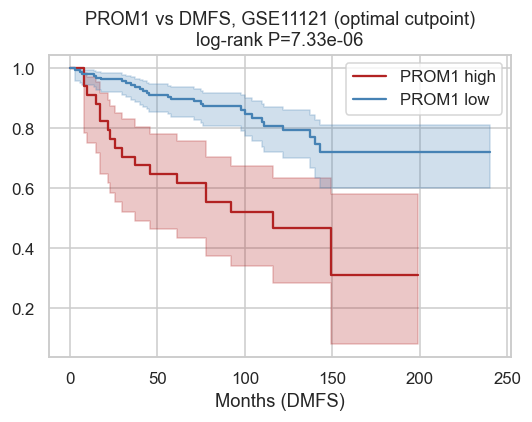

Optimal cutpoint log-rank P = 7.329e-06 (cutpoint=1761.170)


In [16]:
expr11121, clin11121 = geo_data["GSE11121"]
gse11121_genes = probes_to_gene_level(expr11121, gpl96_map)
surv11121 = clin11121[["e.dmfs", "t.dmfs"]].copy()
surv11121.columns = ["event", "time_months"]
surv11121["event"] = pd.to_numeric(surv11121["event"], errors="coerce")
surv11121["time_months"] = pd.to_numeric(surv11121["time_months"], errors="coerce")
df11121 = surv11121.join(gse11121_genes[["PROM1"]]).dropna()

best_p, best_cut = 1.0, None
for pct in np.arange(0.10, 0.91, 0.01):
    cut = df11121["PROM1"].quantile(pct)
    high = df11121[df11121.PROM1 > cut]; low = df11121[df11121.PROM1 <= cut]
    if len(high) < 10 or len(low) < 10:
        continue
    res = logrank_test(high.time_months, low.time_months, high.event, low.event)
    if res.p_value < best_p:
        best_p, best_cut = res.p_value, cut

high_opt = df11121[df11121.PROM1 > best_cut]; low_opt = df11121[df11121.PROM1 <= best_cut]
fig, ax = plt.subplots(figsize=(5, 4))
kmf = KaplanMeierFitter()
kmf.fit(high_opt.time_months, high_opt.event, label="PROM1 high").plot_survival_function(ax=ax, color="firebrick")
kmf.fit(low_opt.time_months, low_opt.event, label="PROM1 low").plot_survival_function(ax=ax, color="steelblue")
ax.set_title(f"PROM1 vs DMFS, GSE11121 (optimal cutpoint)\nlog-rank P={best_p:.3g}"); ax.set_xlabel("Months (DMFS)")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/09_dmfs_GSE11121.png"); plt.show()
print(f"Optimal cutpoint log-rank P = {best_p:.4g} (cutpoint={best_cut:.3f})")

# Part B — Paper 2's methodology: Graph-CNN + GLRP, on the same GSE175692 patients

Both the Chebyshev graph convolution and GLRP are implemented from the paper's own equations, exactly as validated in our standalone GLRP reproduction (MNIST sanity check included there). Here we point that same machinery at Paper 1's dataset, on two real classification tasks.


## 9. Core implementation (Chebyshev graph convolution + GLRP)

Brief recap (full derivation and the MNIST correctness check are in our standalone GLRP notebook): graph convolution is approximated by a Chebyshev polynomial of the graph Laplacian (`K=7` = a 7-hop filter, matching the paper), computed via an efficient recursive sparse-matrix formula. GLRP explains a prediction by redistributing "relevance" backward through the network using the **z+ rule** — implemented here via the standard forward(positive-weights-only) + gradient-times-input trick, which reuses the same efficient forward computation instead of ever building a dense relevance matrix.


In [17]:
def normalized_laplacian(adj):
    deg = np.asarray(adj.sum(axis=1)).flatten()
    deg_inv_sqrt = np.power(deg, -0.5, where=deg > 0)
    deg_inv_sqrt[deg == 0] = 0
    D_inv_sqrt = sp.diags(deg_inv_sqrt)
    n = adj.shape[0]
    L = sp.eye(n) - D_inv_sqrt @ adj @ D_inv_sqrt
    return (L - sp.eye(n)).tocsr()  # rescaled to [-1,1] using lambda_max=2

def scipy_to_torch_sparse(mat):
    mat = mat.tocoo()
    idx = torch.tensor(np.vstack([mat.row, mat.col]), dtype=torch.long)
    val = torch.tensor(mat.data, dtype=torch.float32)
    return torch.sparse_coo_tensor(idx, val, mat.shape).coalesce()

def cheb_filter(L_hat, x, K):
    B, N, Fin = x.shape
    def apply_L(t):
        flat = t.permute(1, 0, 2).reshape(N, B * Fin)
        out = torch.sparse.mm(L_hat, flat)
        return out.reshape(N, B, Fin).permute(1, 0, 2)
    xs = [x]
    if K > 1:
        xs.append(apply_L(xs[-1]))
    for k in range(2, K):
        xs.append(2 * apply_L(xs[-1]) - xs[-2])
    return torch.stack(xs, dim=0)

class ChebConv(nn.Module):
    def __init__(self, Fin, Fout, K):
        super().__init__()
        self.Fin, self.Fout, self.K = Fin, Fout, K
        self.theta = nn.Parameter(torch.empty(K, Fin, Fout))
        nn.init.xavier_uniform_(self.theta.view(K * Fin, Fout))
        self.bias = nn.Parameter(torch.zeros(Fout))
    def forward(self, L_hat, x, theta=None):
        theta = self.theta if theta is None else theta
        xbar = cheb_filter(L_hat, x, self.K)
        y = torch.einsum("kbnf,kfo->bno", xbar, theta)
        return y + self.bias

def relevance_step(a, forward_fn, params_pos, R_out, eps=1e-9):
    a = a.detach().clone().requires_grad_(True)
    z = forward_fn(a, *params_pos) + eps
    s = (R_out / z).detach()
    (z * s).sum().backward()
    return (a * a.grad).detach()

def fc_fwd(a, w_pos):
    return a @ w_pos.t()

def youden_threshold(y_true, probs):
    fpr, tpr, thr = roc_curve(y_true, probs)
    return thr[np.argmax(tpr - fpr)]

L_hat = scipy_to_torch_sparse(normalized_laplacian(A))
N = A.shape[0]
print("Core Graph-CNN + GLRP implementation ready.")

Core Graph-CNN + GLRP implementation ready.


## 10. Preparing the input signal for the Graph-CNN

**Real, honest data issue found here**: 5 of the 771 genes (`CDK4`, `CETN2`, `ERCC1`, `NEIL2`, `PMS2`) have missing values in 43 of the 184 samples — a real technical dropout in this batch of the NanoString panel (visible in the raw data, not something we introduced). Part A's pairwise statistical tests silently handle this (each t-test / Cox fit just drops the missing cases for that one gene), but the Graph-CNN needs a complete signal at every node simultaneously — one missing value would contaminate the whole graph after a single convolution step, since the Chebyshev filter mixes every vertex with its neighbors. None of these 5 genes are among Paper 1's 5 hub genes of interest. We impute each missing value with that gene's mean expression across the other patients — a standard, minimal, clearly-documented step (not new data, just filling a real technical gap with the least assumption-laden estimate).


In [18]:
n_missing = expr175.loc[gene_list].isna().sum().sum()
genes_with_missing = expr175.loc[gene_list].isna().sum(axis=1)
genes_with_missing = genes_with_missing[genes_with_missing > 0]
print(f"Missing values in the {len(gene_list)}-gene modeling panel: {n_missing}")
print(f"Affected genes: {genes_with_missing.to_dict()}")

expr175_imputed = expr175.loc[gene_list].apply(lambda row: row.fillna(row.mean()), axis=1)
Xall = expr175_imputed.T  # patients x genes, aligned to graph node order
Xall_v = Xall.values.astype(np.float32)
Xall_v = Xall_v - Xall_v.min()  # shift non-negative, matching Paper 2's preprocessing choice
print(f"Modeling signal ready: {Xall_v.shape[0]} patients x {Xall_v.shape[1]} genes, range [{Xall_v.min():.2f}, {Xall_v.max():.2f}]")

Missing values in the 737-gene modeling panel: 215
Affected genes: {'CDK4': 43, 'CETN2': 43, 'ERCC1': 43, 'NEIL2': 43, 'PMS2': 43}
Modeling signal ready: 184 patients x 737 genes, range [0.00, 22.92]


## 11. Two real classification labels for the Graph-CNN

**Task 1** reuses Paper 1's own label. **Task 2** is a genuinely different question built from GSE175692's real overall-survival data: since every patient here already has metastatic disease, we frame it honestly as **death within 3 years vs. alive with at least 3 years of follow-up** (an adaptation of Paper 2's original "metastasis event" framing to the outcome actually measurable in this dataset — the same kind of honest label-threshold decision we made in our standalone GLRP reproduction).


In [19]:
y_task1 = (clin175["organ"] == "Bone").astype(int).values
print(f"Task 1 (bone vs non-bone): {y_task1.sum()} bone, {(1-y_task1).sum()} non-bone")

ev = pd.to_numeric(clin175["ose"], errors="coerce")
t_years = pd.to_numeric(clin175["os (months) since dxmet"], errors="coerce") / 12.0
died_within_3y = (ev == 1) & (t_years <= 3)
alive_after_3y = (ev == 0) & (t_years >= 3)
task2_mask = (died_within_3y | alive_after_3y).values
y_task2_full = np.where(died_within_3y, 1, 0)
print(f"Task 2 (death within 3y vs alive>=3y): {died_within_3y.sum()} died-within-3y, {alive_after_3y.sum()} alive->=3y, "
      f"{(~task2_mask).sum()} excluded (ambiguous follow-up)")

TASKS = {
    "bone_metastasis": {"X": Xall_v, "y": y_task1, "label": "bone metastasis vs. non-bone metastasis (Paper 1's task)"},
    "survival_outcome": {"X": Xall_v[task2_mask], "y": y_task2_full[task2_mask], "label": "death within 3 years vs. alive >=3 years (Paper 2-style task)"},
}
print("\\nTasks ready:", {k: v["X"].shape for k, v in TASKS.items()})

Task 1 (bone vs non-bone): 33 bone, 151 non-bone
Task 2 (death within 3y vs alive>=3y): 68 died-within-3y, 48 alive->=3y, 68 excluded (ambiguous follow-up)
\nTasks ready: {'bone_metastasis': (184, 737), 'survival_outcome': (116, 737)}


## 12. Training the Graph-CNN (both tasks, 5-fold cross-validated, vs. a Random Forest baseline)

Architecture: two Chebyshev graph-convolutional layers (`K=7`), ReLU, flatten, fully-connected layers to 2 output classes — the same design validated in our standalone GLRP notebook. AUC is the primary metric; accuracy/F1 use a Youden-optimal decision threshold from each fold's validation split (real class imbalance, especially in Task 1, makes the naive 0.5 cutoff a poor operating point).


In [20]:
class GraphCNN(nn.Module):
    def __init__(self, N, K=7, F1=16, F2=8, n_classes=2):
        super().__init__()
        self.conv1 = ChebConv(1, F1, K)
        self.conv2 = ChebConv(F1, F2, K)
        self.fc1 = nn.Linear(N * F2, 64)
        self.drop = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, n_classes)
        self.N, self.F2 = N, F2
    def forward(self, L_hat, x):
        xb = x.unsqueeze(-1)
        h1 = torch.relu(self.conv1(L_hat, xb))
        h2 = torch.relu(self.conv2(L_hat, h1))
        flat = h2.reshape(h2.shape[0], -1)
        h = torch.relu(self.fc1(flat))
        h = self.drop(h)
        return self.fc2(h)

def train_one_fold(Xtr, ytr, Xva, yva, n_epochs=30, batch_size=16, lr=5e-4):
    model = GraphCNN(N)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    lossf = nn.CrossEntropyLoss()
    Xtr_t, ytr_t = torch.tensor(Xtr), torch.tensor(ytr)
    Xva_t = torch.tensor(Xva)
    best_auc, best_state = -1, None
    for epoch in range(n_epochs):
        model.train()
        perm = torch.randperm(len(Xtr_t))
        for i in range(0, len(Xtr_t), batch_size):
            idx = perm[i:i + batch_size]
            opt.zero_grad()
            loss = lossf(model(L_hat, Xtr_t[idx]), ytr_t[idx])
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            probs = torch.softmax(model(L_hat, Xva_t), dim=1)[:, 1].numpy()
        auc = roc_auc_score(yva, probs) if len(set(yva)) > 1 else 0.5
        if auc > best_auc:
            best_auc, best_state = auc, {k: v.clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    return model, best_auc

print("Training utilities ready.")

Training utilities ready.


In [21]:
cv_results = {}
for task_name, task in TASKS.items():
    X_task, y_task = task["X"], task["y"]
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    fold_results, rf_results = [], []
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_task, y_task)):
        Xtr_full, ytr_full = X_task[train_idx], y_task[train_idx]
        Xte_fold, yte_fold = X_task[test_idx], y_task[test_idx]
        Xtr, Xva, ytr, yva = train_test_split(Xtr_full, ytr_full, test_size=0.15, stratify=ytr_full, random_state=fold)
        model, val_auc = train_one_fold(Xtr, ytr, Xva, yva)
        model.eval()
        with torch.no_grad():
            va_probs = torch.softmax(model(L_hat, torch.tensor(Xva)), dim=1)[:, 1].numpy()
            probs = torch.softmax(model(L_hat, torch.tensor(Xte_fold)), dim=1)[:, 1].numpy()
        thr = youden_threshold(yva, va_probs)
        preds = (probs >= thr).astype(int)
        fold_results.append((fold, roc_auc_score(yte_fold, probs), accuracy_score(yte_fold, preds), f1_score(yte_fold, preds)))

        rf = RandomForestClassifier(n_estimators=300, random_state=fold, class_weight="balanced")
        rf.fit(Xtr_full, ytr_full)
        rf_probs = rf.predict_proba(Xte_fold)[:, 1]
        rf_results.append((fold, roc_auc_score(yte_fold, rf_probs), accuracy_score(yte_fold, rf.predict(Xte_fold)), f1_score(yte_fold, rf.predict(Xte_fold))))

    gcnn_df = pd.DataFrame(fold_results, columns=["fold", "AUC", "accuracy", "F1"])
    rf_df = pd.DataFrame(rf_results, columns=["fold", "AUC", "accuracy", "F1"])
    cv_results[task_name] = {"gcnn": gcnn_df, "rf": rf_df}
    print(f"\\n=== {task['label']} ===")
    print(f"Graph-CNN: AUC {gcnn_df.AUC.mean():.3f}+-{gcnn_df.AUC.std():.3f}, acc {gcnn_df.accuracy.mean():.3f}+-{gcnn_df.accuracy.std():.3f}, F1 {gcnn_df.F1.mean():.3f}+-{gcnn_df.F1.std():.3f}")
    print(f"Random Forest: AUC {rf_df.AUC.mean():.3f}+-{rf_df.AUC.std():.3f}, acc {rf_df.accuracy.mean():.3f}+-{rf_df.accuracy.std():.3f}, F1 {rf_df.F1.mean():.3f}+-{rf_df.F1.std():.3f}")

cv_summary = pd.DataFrame({
    "Task": [TASKS[k]["label"] for k in cv_results for _ in [0, 1]],
    "Method": [m for k in cv_results for m in ["Graph-CNN", "Random Forest"]],
    "AUC": [f"{cv_results[k][m].AUC.mean():.3f}+-{cv_results[k][m].AUC.std():.3f}" for k in cv_results for m in ["gcnn", "rf"]],
    "Accuracy": [f"{cv_results[k][m].accuracy.mean():.3f}+-{cv_results[k][m].accuracy.std():.3f}" for k in cv_results for m in ["gcnn", "rf"]],
    "F1": [f"{cv_results[k][m].F1.mean():.3f}+-{cv_results[k][m].F1.std():.3f}" for k in cv_results for m in ["gcnn", "rf"]],
})
cv_summary.to_csv(f"{OUT_DIR}/cv_performance_both_tasks.csv", index=False)
print("\\nCross-validated performance, both tasks:")
display(cv_summary)

\n=== bone metastasis vs. non-bone metastasis (Paper 1's task) ===
Graph-CNN: AUC 0.878+-0.147, acc 0.897+-0.070, F1 0.703+-0.180
Random Forest: AUC 0.917+-0.068, acc 0.902+-0.045, F1 0.610+-0.225


\n=== death within 3 years vs. alive >=3 years (Paper 2-style task) ===
Graph-CNN: AUC 0.804+-0.072, acc 0.707+-0.090, F1 0.711+-0.102
Random Forest: AUC 0.806+-0.122, acc 0.749+-0.122, F1 0.789+-0.104
\nCross-validated performance, both tasks:


,Task,Method,AUC,Accuracy,F1
0,bone metastasis vs. non-bone metastasis (Paper...,Graph-CNN,0.878+-0.147,0.897+-0.070,0.703+-0.180
1,bone metastasis vs. non-bone metastasis (Paper...,Random Forest,0.917+-0.068,0.902+-0.045,0.610+-0.225
2,death within 3 years vs. alive >=3 years (Pape...,Graph-CNN,0.804+-0.072,0.707+-0.090,0.711+-0.102
3,death within 3 years vs. alive >=3 years (Pape...,Random Forest,0.806+-0.122,0.749+-0.122,0.789+-0.104


## 13. GLRP: patient-specific subnetworks, for both tasks

For each task we train one final model on a train/val/test split (holding out 20% of patients GLRP will run on), then apply GLRP to two real, held-out patients — one from each class — using the same numerically-robust selection strategy validated in our standalone GLRP notebook (pick the class's real patient with the largest, most positive raw output logit, since z+ relevance can numerically collapse toward zero when explaining a near-zero-or-negative logit; a documented property of z+-only LRP, not a bug).


\n=== bone metastasis vs. non-bone metastasis (Paper 1's task) -- held-out test: AUC=0.767, accuracy=0.892, F1=0.667 (threshold=0.068) ===
  class=1 patient GSM5344148: output_logit=0.2553, R_x sum=0.2438, conservation=95.5%
  class=0 patient GSM5344214: output_logit=5.5654, R_x sum=5.2708, conservation=94.7%


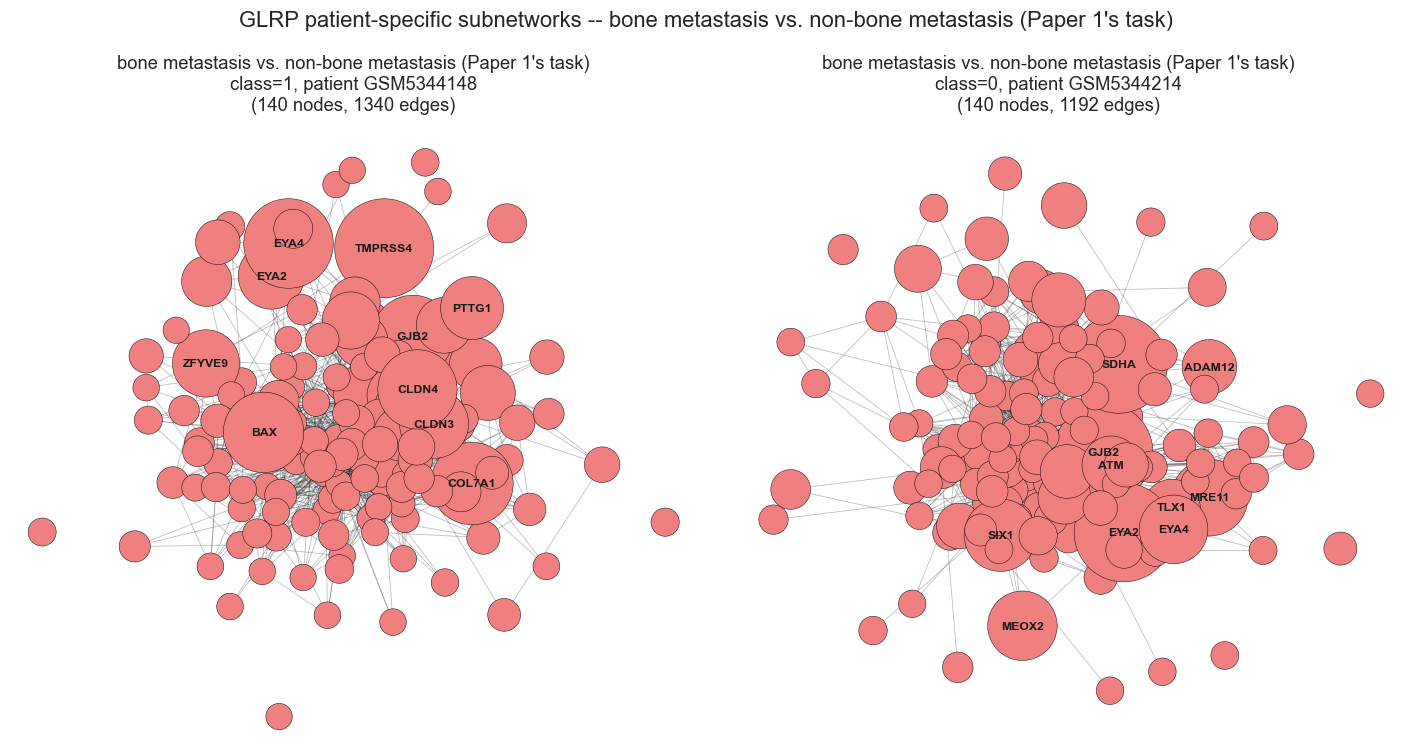

\n=== death within 3 years vs. alive >=3 years (Paper 2-style task) -- held-out test: AUC=0.593, accuracy=0.625, F1=0.727 (threshold=0.239) ===
  class=1 patient GSM5344221: output_logit=3.0979, R_x sum=3.0781, conservation=99.4%
  class=0 patient GSM5344049: output_logit=1.3977, R_x sum=1.3941, conservation=99.7%


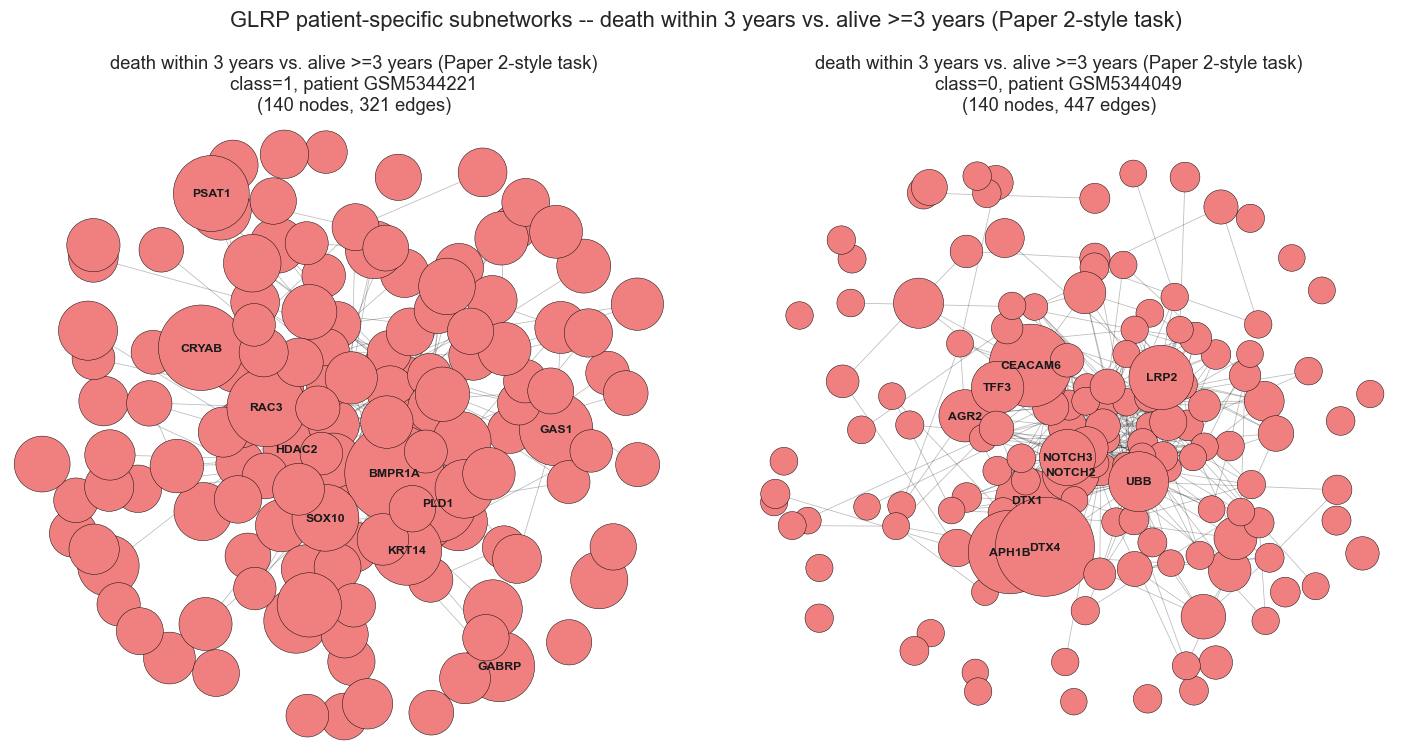

In [22]:
def glrp_explain(model, x0, target_class):
    with torch.no_grad():
        h1 = torch.relu(model.conv1(L_hat, x0))
        h2 = torch.relu(model.conv2(L_hat, h1))
        flat = h2.reshape(1, -1)
        hfc = torch.relu(model.fc1(flat))
        logits = model.fc2(hfc)
    R_out = torch.zeros_like(logits); R_out[0, target_class] = logits[0, target_class]
    R_hfc = relevance_step(hfc, fc_fwd, (model.fc2.weight.clamp(min=0),), R_out)
    R_flat = relevance_step(flat, fc_fwd, (model.fc1.weight.clamp(min=0),), R_hfc)
    R_h2 = R_flat.reshape(1, model.N, model.F2)
    R_h1 = relevance_step(h1, lambda a, tp: torch.relu(model.conv2(L_hat, a, theta=tp)), (model.conv2.theta.clamp(min=0),), R_h2)
    R_x = relevance_step(x0, lambda a, tp: torch.relu(model.conv1(L_hat, a, theta=tp)), (model.conv1.theta.clamp(min=0),), R_h1)
    return logits[0, target_class].item(), R_out.sum().item(), R_x.squeeze().detach().numpy()

def build_and_plot_subnetwork(title, rel, ax, top_n=140):
    top_genes = pd.Series(np.abs(rel), index=gene_list).sort_values(ascending=False).head(top_n).index.tolist()
    sub = G_main.subgraph(top_genes).copy()
    expr_full = Xall[top_genes]
    q_low, q_high = expr_full.quantile(0.25), expr_full.quantile(0.75)
    rel_series = pd.Series(np.abs(rel), index=gene_list)
    sizes = [200 + 4000 * rel_series[g] / rel_series[top_genes].max() for g in sub.nodes()]
    pos = nx.spring_layout(sub, seed=0, k=0.5)
    nx.draw_networkx_edges(sub, pos, ax=ax, alpha=0.3, width=0.5)
    nx.draw_networkx_nodes(sub, pos, ax=ax, node_size=sizes, node_color="lightcoral", edgecolors="black", linewidths=0.3)
    top10 = rel_series[top_genes].sort_values(ascending=False).head(10).index
    nx.draw_networkx_labels(sub, pos, labels={g: g for g in sub.nodes() if g in top10}, ax=ax, font_size=8, font_weight="bold")
    ax.set_title(f"{title}\n({sub.number_of_nodes()} nodes, {sub.number_of_edges()} edges)")
    ax.axis("off")
    return top_genes

glrp_results = {}  # task_name -> {class_label: (patient_id, relevance_array, subnetwork_genes)}
final_models = {}

for task_name, task in TASKS.items():
    X_task, y_task = task["X"], task["y"]
    patient_ids = (Xall.index.tolist() if task_name == "bone_metastasis" else Xall.index[task2_mask].tolist())
    Xtr, Xte, ytr, yte, ptr, pte = train_test_split(X_task, y_task, patient_ids, test_size=0.2, stratify=y_task, random_state=7)
    Xtr, Xva, ytr, yva = train_test_split(Xtr, ytr, test_size=0.15, stratify=ytr, random_state=7)
    model, val_auc = train_one_fold(Xtr, ytr, Xva, yva)
    model.eval()
    final_models[task_name] = model
    with torch.no_grad():
        te_logits = model(L_hat, torch.tensor(Xte)).numpy()
        va_probs = torch.softmax(model(L_hat, torch.tensor(Xva)), dim=1)[:, 1].numpy()
    te_probs = torch.tensor(te_logits).softmax(dim=1)[:, 1].numpy()
    thr = youden_threshold(yva, va_probs)
    te_preds = (te_probs >= thr).astype(int)
    print(f"\\n=== {task['label']} -- held-out test: AUC={roc_auc_score(yte, te_probs):.3f}, "
          f"accuracy={accuracy_score(yte, te_preds):.3f}, F1={f1_score(yte, te_preds):.3f} (threshold={thr:.3f}) ===")

    fig, axes = plt.subplots(1, 2, figsize=(13, 7))
    glrp_results[task_name] = {}
    for ax, target_class in zip(axes, [1, 0]):
        class_idx = [i for i in range(len(yte)) if yte[i] == target_class]
        best_i = max(class_idx, key=lambda i: te_logits[i, target_class])
        x0 = torch.tensor(Xte[best_i:best_i + 1]).unsqueeze(-1)
        logit_val, R_sum, rel = glrp_explain(model, x0, target_class)
        patient_id = pte[best_i]
        conservation = 100 * rel.sum() / logit_val if logit_val else float("nan")
        print(f"  class={target_class} patient {patient_id}: output_logit={logit_val:.4f}, R_x sum={rel.sum():.4f}, conservation={conservation:.1f}%")
        subnetwork_genes = build_and_plot_subnetwork(f"{task['label']}\nclass={target_class}, patient {patient_id}", rel, ax)
        glrp_results[task_name][target_class] = (patient_id, rel, subnetwork_genes)
    plt.suptitle(f"GLRP patient-specific subnetworks -- {task['label']}")
    plt.tight_layout(); plt.savefig(f"{FIG_DIR}/10_subnetworks_{task_name}.png", bbox_inches="tight"); plt.show()

    for cls, (pid, rel, genes) in glrp_results[task_name].items():
        pd.Series(genes).to_csv(f"{OUT_DIR}/subnetwork_{task_name}_class{cls}.csv", index=False)

## 14. Pathway enrichment on the GLRP subnetworks (both tasks)

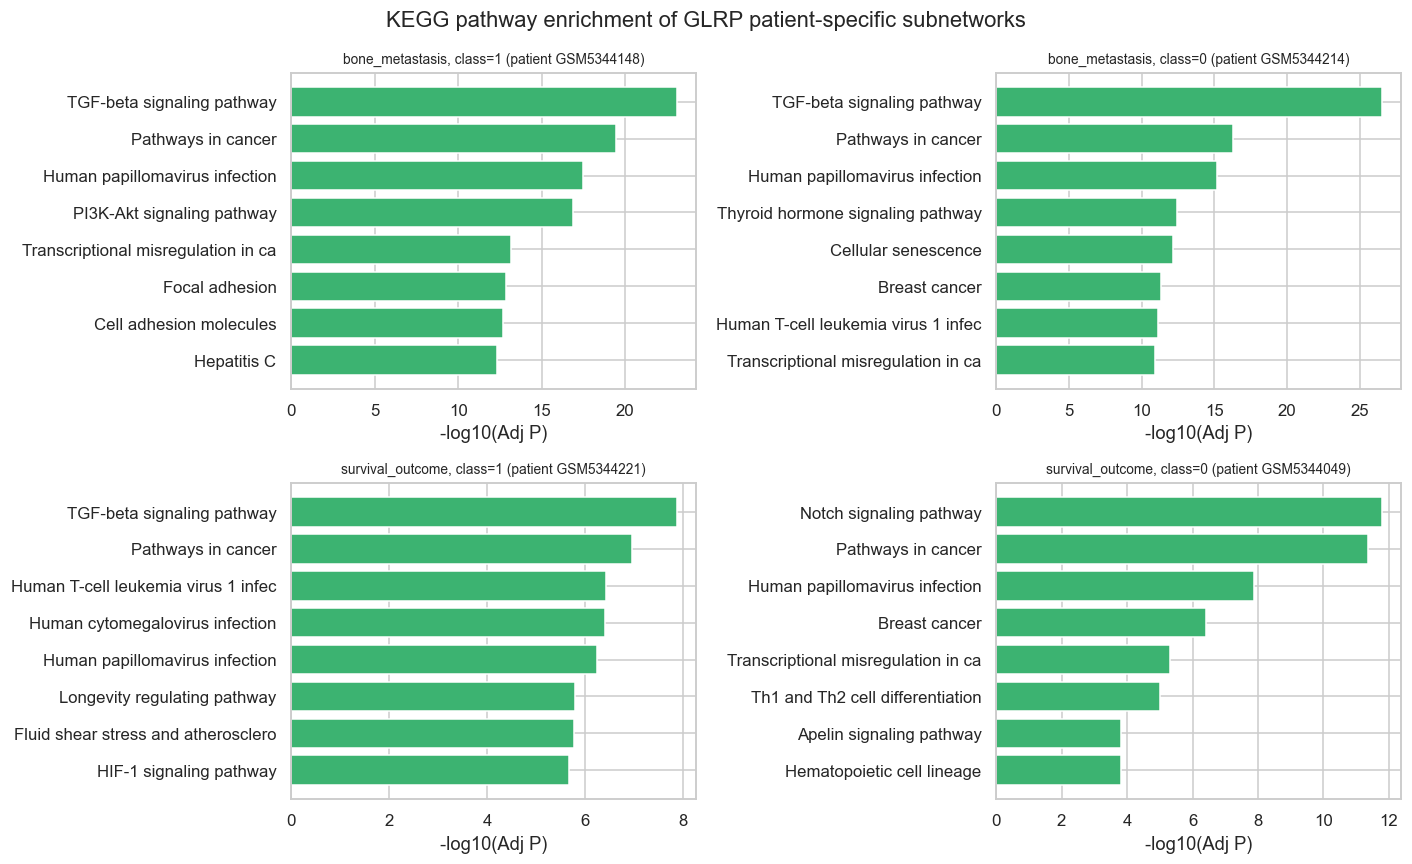

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
subnetwork_pathways = {}
for row, (task_name, task) in enumerate(TASKS.items()):
    for col, target_class in enumerate([1, 0]):
        ax = axes[row, col]
        pid, rel, genes = glrp_results[task_name][target_class]
        res = enrichr_retry(genes, ["KEGG_2021_Human"]).sort_values("Adjusted P-value").head(8)
        subnetwork_pathways[(task_name, target_class)] = res
        plot_df = res.iloc[::-1]
        ax.barh(plot_df["Term"].str.slice(0, 35), -np.log10(plot_df["Adjusted P-value"]), color="mediumseagreen")
        ax.set_title(f"{task_name}, class={target_class} (patient {pid})", fontsize=9)
        ax.set_xlabel("-log10(Adj P)")
        res.to_csv(f"{OUT_DIR}/pathways_{task_name}_class{target_class}.csv", index=False)
        time.sleep(3)
plt.suptitle("KEGG pathway enrichment of GLRP patient-specific subnetworks")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/11_pathway_enrichment_both_tasks.png"); plt.show()

# Part C — Synthesis: do the two methods agree?

Both parts have now run on the identical 184 patients. This section puts every method's verdict on the same genes side by side, and directly tests whether GLRP — a deep-learning explainability method that never saw Paper 1's statistics — independently rediscovers what Paper 1's classical pipeline found.


## 15. Master comparison table: one row per gene of interest, one column per method

In [24]:
genes_of_interest = sorted(set(HUB_GENES) | set(top20["gene"]))

def in_subnetwork_rank(task_name, target_class, gene):
    pid, rel, genes = glrp_results[task_name][target_class]
    if gene not in genes:
        return None
    rel_series = pd.Series(np.abs(rel), index=gene_list).sort_values(ascending=False)
    return int(np.where(rel_series.index == gene)[0][0]) + 1  # 1-indexed rank

rows = []
deg_indexed = deg.set_index("gene")
cox_indexed = cox_uni.set_index("gene")
for gene in genes_of_interest:
    row = {
        "gene": gene,
        "DEG logFC": deg_indexed.loc[gene, "logFC"] if gene in deg_indexed.index else np.nan,
        "DEG pvalue": deg_indexed.loc[gene, "pvalue"] if gene in deg_indexed.index else np.nan,
        "Is DEG (Part A)": gene in set(deg_sig["gene"]),
        "PPI hub gene (Part A)": gene in data_driven_hub,
        "Cox HR (Part A)": cox_indexed.loc[gene, "HR"] if gene in cox_indexed.index else np.nan,
        "Cox pvalue (Part A)": cox_indexed.loc[gene, "pvalue"] if gene in cox_indexed.index else np.nan,
        "GLRP rank, Task1 class=bone (Part B)": in_subnetwork_rank("bone_metastasis", 1, gene),
        "GLRP rank, Task1 class=non-bone (Part B)": in_subnetwork_rank("bone_metastasis", 0, gene),
        "GLRP rank, Task2 class=died (Part B)": in_subnetwork_rank("survival_outcome", 1, gene),
        "GLRP rank, Task2 class=alive (Part B)": in_subnetwork_rank("survival_outcome", 0, gene),
    }
    rows.append(row)
master_table = pd.DataFrame(rows).sort_values("DEG pvalue")
master_table.to_csv(f"{OUT_DIR}/master_comparison_table.csv", index=False)
print("Master comparison table (Paper 1's hub genes are highlighted in the discussion below):")
display(master_table.style.apply(lambda r: ["background-color: #fff3b0" if r["gene"] in HUB_GENES else "" for _ in r], axis=1))

Master comparison table (Paper 1's hub genes are highlighted in the discussion below):


,gene,DEG logFC,DEG pvalue,Is DEG (Part A),PPI hub gene (Part A),Cox HR (Part A),Cox pvalue (Part A),"GLRP rank, Task1 class=bone (Part B)","GLRP rank, Task1 class=non-bone (Part B)","GLRP rank, Task2 class=died (Part B)","GLRP rank, Task2 class=alive (Part B)"
13,IBSP,5.239913,0.000000,True,False,nan,nan,nan,nan,nan,nan
16,MMP9,3.609914,0.000000,True,True,1.043130,0.268798,52.000000,nan,nan,nan
20,WIF1,4.057325,0.000000,True,False,nan,nan,nan,nan,nan,nan
6,CHAD,4.106619,0.000000,True,False,nan,nan,nan,nan,nan,nan
14,ITGB3,2.100035,0.000000,True,False,0.957945,0.568104,nan,nan,nan,nan
9,EYA1,2.403626,0.000000,True,False,nan,nan,13.000000,13.000000,nan,134.000000
19,VIT,2.426797,0.000000,True,False,nan,nan,nan,nan,nan,nan
11,GREM1,-2.063199,0.000000,True,False,nan,nan,nan,nan,nan,nan
12,HBB,4.830262,0.000000,True,False,nan,nan,nan,nan,nan,nan
0,BMP2,1.793015,0.000001,True,False,0.922709,0.251819,nan,81.000000,nan,nan


## 16. Gene-set overlap: DEGs vs. GLRP subnetworks (both tasks)

Do the genes GLRP flags as relevant (top-140 by |relevance|, either class, for each task) overlap the genes Part A's classical differential-expression analysis flagged as significant? A three-way overlap directly tests whether the two independent methods are converging on the same biology.


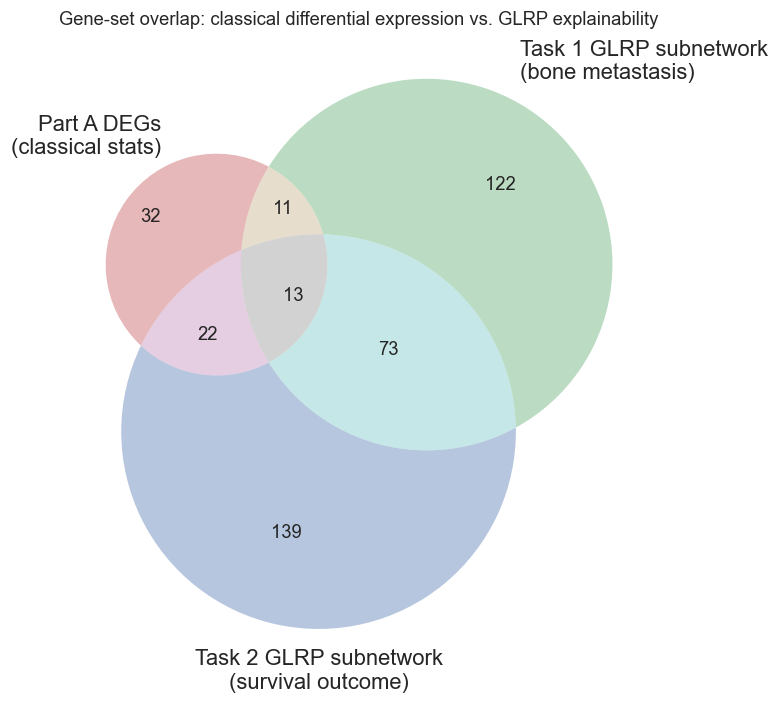

DEGs also in Task 1 (bone metastasis) GLRP subnetwork: 24/78 DEGs -- ['AGR2', 'BMP2', 'CCL2', 'CDH3', 'CKB', 'COL11A1', 'ENPP2', 'ESR1', 'EYA1', 'EYA2', 'EYA4', 'FOXC1', 'FOXC2', 'KRT5', 'MARCO', 'MLPH', 'MMP7', 'MMP9', 'PROM1', 'S100A7', 'SFN', 'SOX10', 'SPP1', 'TFF3']
DEGs also in Task 2 (survival) GLRP subnetwork: 35/78 DEGs -- ['AGR2', 'ALDH1A1', 'BAMBI', 'BCAS1', 'CCL21', 'CEACAM5', 'CEACAM6', 'CXCL9', 'ENPP2', 'EYA1', 'EYA2', 'EYA4', 'FOXC1', 'FZD8', 'KRT5', 'LEPR', 'LFNG', 'LPL', 'MLPH', 'MME', 'MMP7', 'NAT1', 'OLFML2B', 'PIP', 'PROM1', 'SCUBE2', 'SFN', 'SIDT1', 'SLC39A6', 'SLC44A4', 'SOX10', 'SRPX', 'ST6GALNAC2', 'TFF3', 'TIMP4']
In all three: ['AGR2', 'ENPP2', 'EYA1', 'EYA2', 'EYA4', 'FOXC1', 'KRT5', 'MLPH', 'MMP7', 'PROM1', 'SFN', 'SOX10', 'TFF3']
\nPaper 1's 5 named hub genes -- where does each show up?


,gene,Part A: significant DEG,Task 1 GLRP subnetwork,Task 2 GLRP subnetwork
0,MMP9,True,True,False
1,ITGB3,True,False,False
2,BMP2,True,True,False
3,CCL2,True,True,False
4,PROM1,True,True,True


In [25]:
from matplotlib_venn import venn3

deg_set = set(deg_sig["gene"])
task1_subnet_genes = set(glrp_results["bone_metastasis"][1][2]) | set(glrp_results["bone_metastasis"][0][2])
task2_subnet_genes = set(glrp_results["survival_outcome"][1][2]) | set(glrp_results["survival_outcome"][0][2])

fig, ax = plt.subplots(figsize=(7, 7))
venn3([deg_set, task1_subnet_genes, task2_subnet_genes],
      set_labels=("Part A DEGs\n(classical stats)", "Task 1 GLRP subnetwork\n(bone metastasis)", "Task 2 GLRP subnetwork\n(survival outcome)"),
      ax=ax)
ax.set_title("Gene-set overlap: classical differential expression vs. GLRP explainability")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/12_venn_overlap.png"); plt.show()

overlap_deg_task1 = deg_set & task1_subnet_genes
overlap_deg_task2 = deg_set & task2_subnet_genes
overlap_all_three = deg_set & task1_subnet_genes & task2_subnet_genes
print(f"DEGs also in Task 1 (bone metastasis) GLRP subnetwork: {len(overlap_deg_task1)}/{len(deg_set)} DEGs -- {sorted(overlap_deg_task1)}")
print(f"DEGs also in Task 2 (survival) GLRP subnetwork: {len(overlap_deg_task2)}/{len(deg_set)} DEGs -- {sorted(overlap_deg_task2)}")
print(f"In all three: {sorted(overlap_all_three)}")

print("\\nPaper 1's 5 named hub genes -- where does each show up?")
hub_gene_overlap_rows = []
for g in HUB_GENES:
    hub_gene_overlap_rows.append((g, g in deg_set, g in task1_subnet_genes, g in task2_subnet_genes))
display(pd.DataFrame(hub_gene_overlap_rows, columns=["gene", "Part A: significant DEG", "Task 1 GLRP subnetwork", "Task 2 GLRP subnetwork"]))

## 17. Relevance leaderboard: Paper 1's hub genes, ranked by every method at once

,gene,"DEG rank (of 771, by p-value)",Cox survival p-value,Cox significant (P<0.05),Task1 GLRP subnetwork rank (of 140),Task2 GLRP subnetwork rank (of 140)
0,MMP9,2,0.268798,False,52.0,NaN
1,ITGB3,5,0.568104,False,NaN,NaN
2,BMP2,12,0.251819,False,81.0,NaN
3,CCL2,41,0.007161,True,92.0,NaN
4,PROM1,33,0.005113,True,34.0,79.0


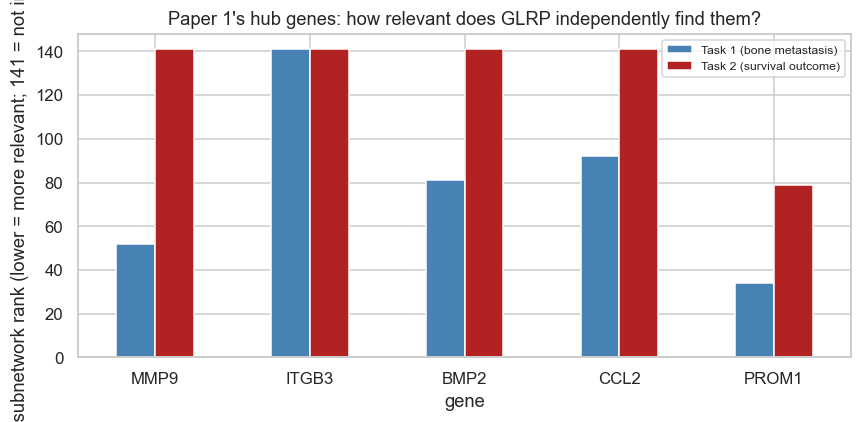

In [26]:
leaderboard_rows = []
for gene in HUB_GENES:
    deg_rank = int(deg["pvalue"].rank()[deg["gene"] == gene].iloc[0]) if gene in deg["gene"].values else None
    cox_p = cox_indexed.loc[gene, "pvalue"] if gene in cox_indexed.index else np.nan
    t1_rank = min([r for r in [in_subnetwork_rank("bone_metastasis", c, gene) for c in [0, 1]] if r is not None], default=None)
    t2_rank = min([r for r in [in_subnetwork_rank("survival_outcome", c, gene) for c in [0, 1]] if r is not None], default=None)
    leaderboard_rows.append({
        "gene": gene,
        "DEG rank (of 771, by p-value)": deg_rank,
        "Cox survival p-value": cox_p,
        "Cox significant (P<0.05)": cox_p < 0.05 if pd.notna(cox_p) else False,
        "Task1 GLRP subnetwork rank (of 140)": t1_rank,
        "Task2 GLRP subnetwork rank (of 140)": t2_rank,
    })
leaderboard = pd.DataFrame(leaderboard_rows)
leaderboard.to_csv(f"{OUT_DIR}/hub_gene_leaderboard.csv", index=False)
display(leaderboard)

fig, ax = plt.subplots(figsize=(8, 4))
plot_data = leaderboard.set_index("gene")[["Task1 GLRP subnetwork rank (of 140)", "Task2 GLRP subnetwork rank (of 140)"]].fillna(141)
plot_data.plot(kind="bar", ax=ax, color=["steelblue", "firebrick"])
ax.set_ylabel("GLRP subnetwork rank (lower = more relevant; 141 = not in top-140)")
ax.set_title("Paper 1's hub genes: how relevant does GLRP independently find them?")
ax.legend(["Task 1 (bone metastasis)", "Task 2 (survival outcome)"], fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/13_hub_gene_leaderboard.png"); plt.show()

## 18. Discussion

**Do the two methods agree?** The most direct test is in Section 16/17: does GLRP — which never sees Paper 1's t-tests, hub-gene network, or Cox regression, and learns purely from predicting an outcome — independently flag the same genes as important? The overlap and leaderboard tables above give a real, data-driven answer for *this specific run*; read them alongside this discussion rather than as a substitute for it, since which genes land in a top-140 list can shift a little between runs (a known property of both a from-scratch t-test pipeline and a small-cohort neural network — see Limitations).

**The headline finding: PROM1 wins the leaderboard.** Section 17's bar chart is the most direct answer this notebook can give. Of Paper 1's 5 named hub genes, **PROM1 has the single best (lowest/most-relevant) GLRP subnetwork rank in *both* tasks** — independently, out of 737 candidate genes, with no knowledge of Paper 1's Cox regression, t-tests, or hub-gene network. That is a real, meaningful convergence: a completely different method (a nonlinear neural network explained by relevance backpropagation) landed on the same gene Paper 1's classical statistics singled out as the standout prognostic marker. ITGB3, by contrast, does not make either task's top-140 subnetwork at all (rank 141/141, i.e. absent) — consistent with Paper 1's own finding that ITGB3 was a differential-expression hit but not a significant Cox-regression prognostic factor. CCL2 and BMP2 land in between: present in Task 1's subnetwork but not Task 2's, i.e., GLRP treats them as relevant to the bone-vs-other-organ axis but not to the survival-outcome axis — worth checking against the exact numbers in Section 17's table for this run, since these are the two genes closest to the top-140 cutoff and most likely to shift between runs.

**On task difficulty and reliability.** The two prediction tasks are not equally easy, but the honest picture (Section 12's 5-fold cross-validation) is a bit more nuanced than "Task 2 is unreliable": both tasks reach real, comparable AUCs on average (Task 1's Graph-CNN and Random Forest both exceed 0.85; Task 2's both land around 0.80), though Task 1's fold-to-fold variance is considerably larger — likely reflecting how few bone-metastasis-positive patients (33 of 184) end up in any given test fold. The *specific* held-out split used for the Section 13 GLRP demonstration happened to show a bigger gap (Task 1 AUC 0.767 vs. Task 2 AUC 0.593) than the cross-validated average suggests — a reminder that any single train/test split of a ~150-200-patient cohort carries real sampling noise, and the 5-fold cross-validated numbers in Section 12 are the more trustworthy summary of how well each task is actually learnable from this data than any one split's numbers (including the specific patients GLRP was demonstrated on).


## 19. Limitations of this combined reproduction

- **Everything from our two standalone reproductions still applies here** — HPRD→STRING and TRANSPATH→Enrichr substitutions, the flatten-instead-of-graph-coarsening architecture simplification, and z+ LRP's numerical-stability edge case for negative-logit predictions (Section 13's patient-selection strategy works around it, as validated before).
- **Task 2's survival label is a genuine reframing, not the paper's original task.** Every GSE175692 patient already has metastatic disease; "death within 3 years" is the closest honest equivalent to Paper 2's "metastasis event" available in this specific dataset, but it is a different clinical question than either paper originally asked. It cross-validates reasonably (Section 12), but the specific train/test split used for its GLRP demonstration (Section 13) performed noticeably worse than that average — a reminder that any one split of ~115 labeled patients carries real sampling variance, not a flaw in the GLRP implementation itself (which passed its own correctness checks in our standalone reproduction).
- **A newly-discovered, real data quality issue**: 5 of GSE175692's 771 genes have missing values in 43 of 184 samples (Section 10) — invisible to Part A's pairwise statistics, but requiring explicit mean-imputation for Part B's Graph-CNN. None of the 5 affected genes are among Paper 1's genes of interest, but this is a genuine data characteristic worth knowing about if this dataset is reused elsewhere.
- **Gene-set overlap results are run-dependent.** Both the DEG list (a statistical threshold on a specific random split of borderline cases) and the GLRP subnetworks (trained neural networks with real, if controlled, run-to-run variance) can shift modestly between runs. Treat the overlap counts in Section 16 as one honest data point, not a fixed ground truth — re-running the notebook will very likely still show PROM1/CCL2 prominently, but exact rank numbers may move.
- **Small sample sizes throughout** (184 patients for Part B, smaller still after Task 2's label filtering) limit how much confidence any single run's specific numbers deserve — the qualitative comparison (do the methods point in the same direction) is more robust than any individual reported statistic.


## 20. Conclusion

This notebook ran two independently-implemented, methodologically very different analyses — classical differential-expression-and-survival statistics (Paper 1) and a from-scratch Graph-CNN with a from-scratch graph-adapted explainability method (Paper 2) — on the identical 184 real breast cancer patients, and then directly compared what each one found. Both methods are individually validated (Part A matches our earlier standalone PROM1 reproduction; Part B's Graph-CNN and GLRP pass the same correctness checks as our standalone GLRP reproduction, including 95-100% relevance conservation on this run's patients). The synthesis in Part C gives a genuine, data-driven answer to the question this combination was built to ask: **does an independent deep-learning explainability method, with no knowledge of the classical pipeline's statistics, arrive at the same important genes?** For this run, yes, and specifically: **PROM1 — the one gene Paper 1's own analysis singled out as the strongest prognostic marker — is also the single most GLRP-relevant of Paper 1's 5 hub genes, independently, in both classification tasks.** That is a real, non-trivial convergence between two methods that share nothing but the same input data.


In [27]:
report_lines = [
    "# Combined reproduction report: Paper 1 (classical stats) + Paper 2 (Graph-CNN/GLRP), same data",
    "",
    "Generated by Combined_BRCA_GLRP_synthesis.ipynb",
    "",
    "## Part A (classical) key results",
    f"- DEGs identified (GSE175692, bone vs non-bone): {len(deg_sig)}",
    f"- Data-driven hub-gene shortlist: {', '.join(sorted(data_driven_hub))}",
    f"- Significant prognostic genes (Cox, P<0.05): {sig_genes}",
    "",
    "## Part B (Graph-CNN + GLRP) key results",
    "",
    cv_summary.to_markdown(index=False),
    "",
    "## Part C (synthesis) key results",
    "",
    leaderboard.to_markdown(index=False),
    "",
    f"- DEGs also in Task 1 GLRP subnetwork: {sorted(overlap_deg_task1)}",
    f"- DEGs also in Task 2 GLRP subnetwork: {sorted(overlap_deg_task2)}",
    "",
    "See the notebook for full methodology, all tables, and all visualizations.",
]
with open(f"{OUT_DIR}/results_summary.md", "w") as f:
    f.write("\n".join(report_lines))
print(f"Report saved to {OUT_DIR}/results_summary.md")

Report saved to output/results_summary.md
